In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, fbeta_score

In [5]:
from pathlib import Path

DATA_DIR = Path("datasets")

for p in DATA_DIR.rglob("*"):
    print(p)

In [6]:
!pip -q install polars


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import polars as pl

In [8]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/abhilashpalit/ml2026")

files = {
    "source1": DATA_DIR / "train_source1.tsv",
    "source2": DATA_DIR / "train_source2.tsv",
    "source3": DATA_DIR / "train_source3.tsv",
    "ground_truth": DATA_DIR / "train_ground_truth.tsv",
    "test1": DATA_DIR / "test_source1.tsv",
    "test2": DATA_DIR / "test_source2.tsv",
    "test3": DATA_DIR / "test_source3.tsv",
}

for name, path in files.items():
    print(name, "->", path.exists(), path)

source1 -> False \kaggle\input\datasets\abhilashpalit\ml2026\train_source1.tsv
source2 -> False \kaggle\input\datasets\abhilashpalit\ml2026\train_source2.tsv
source3 -> False \kaggle\input\datasets\abhilashpalit\ml2026\train_source3.tsv
ground_truth -> False \kaggle\input\datasets\abhilashpalit\ml2026\train_ground_truth.tsv
test1 -> False \kaggle\input\datasets\abhilashpalit\ml2026\test_source1.tsv
test2 -> False \kaggle\input\datasets\abhilashpalit\ml2026\test_source2.tsv
test3 -> False \kaggle\input\datasets\abhilashpalit\ml2026\test_source3.tsv


In [9]:
import polars as pl

In [10]:
gt = pl.read_csv(
    files["ground_truth"],
    separator="\t",
    n_rows=10
)

print(gt)
print(gt.columns)

FileNotFoundError: The system cannot find the path specified. (os error 3): \kaggle\input\datasets\abhilashpalit\ml2026\train_ground_truth.tsv

In [13]:
from pathlib import Path
import polars as pl

DATA_DIR = Path("dataset")

# Lazy scans, so we don't load the entire datasets into RAM
s1 = pl.scan_csv(
    DATA_DIR / "train_source1.tsv",
    separator="\t"
)

s2 = pl.scan_csv(
    DATA_DIR / "train_source2.tsv",
    separator="\t"
)

s3 = pl.scan_csv(
    DATA_DIR / "train_source3.tsv",
    separator="\t"
)

gt = pl.scan_csv(
    DATA_DIR / "train_ground_truth.tsv",
    separator="\t"
)

print("Source 1 rows:", s1.select(pl.len()).collect().item())
print("Source 2 rows:", s2.select(pl.len()).collect().item())
print("Source 3 rows:", s3.select(pl.len()).collect().item())
print("Ground truth rows:", gt.select(pl.len()).collect().item())

Source 1 rows: 2206821
Source 2 rows: 5034616
Source 3 rows: 5285603
Ground truth rows: 2206821


12.5 million source records and 2.2 million S1 entities.

In [14]:
gt_counts = (
    gt
    .with_columns(
        pl.when(
            pl.col("matched_entity_ids").is_null()
            | (pl.col("matched_entity_ids").str.strip_chars() == "")
        )
        .then(0)
        .otherwise(
            pl.col("matched_entity_ids")
            .str.split(",")
            .list.len()
        )
        .alias("match_count")
    )
    .group_by("match_count")
    .len()
    .sort("match_count")
    .collect()
)

print(gt_counts)

shape: (12, 2)
┌─────────────┬────────┐
│ match_count ┆ len    │
│ ---         ┆ ---    │
│ u32         ┆ u32    │
╞═════════════╪════════╡
│ 0           ┆ 123247 │
│ 1           ┆ 119157 │
│ 2           ┆ 375212 │
│ 3           ┆ 530841 │
│ 4           ┆ 484115 │
│ …           ┆ …      │
│ 7           ┆ 63968  │
│ 8           ┆ 18680  │
│ 9           ┆ 4205   │
│ 10          ┆ 534    │
│ 11          ┆ 37     │
└─────────────┴────────┘


In [15]:
for row in gt_counts.sort("match_count").iter_rows():
    print(row)

(0, 123247)
(1, 119157)
(2, 375212)
(3, 530841)
(4, 484115)
(5, 321957)
(6, 164868)
(7, 63968)
(8, 18680)
(9, 4205)
(10, 534)
(11, 37)


In [16]:
# The ground truth contains the IDs themselves, so it is possible to determine whether each match is S2 or S3

In [17]:
gt_full = (
    gt
    .select([
        "source1_entity_id",
        "matched_entity_ids"
    ])
    .collect()
)

gt_full = gt_full.with_columns(
    pl.col("matched_entity_ids")
    .fill_null("")
    .str.split(",")
    .alias("matches")
)

source_distribution = (
    gt_full
    .with_columns([
        pl.col("matches")
        .list.eval(
            pl.element().str.starts_with("S2-")
        )
        .list.sum()
        .alias("s2_count"),

        pl.col("matches")
        .list.eval(
            pl.element().str.starts_with("S3-")
        )
        .list.sum()
        .alias("s3_count")
    ])
)

print(
    source_distribution
    .select(["s2_count", "s3_count"])
    .head(20)
)

shape: (20, 2)
┌──────────┬──────────┐
│ s2_count ┆ s3_count │
│ ---      ┆ ---      │
│ u32      ┆ u32      │
╞══════════╪══════════╡
│ 2        ┆ 3        │
│ 2        ┆ 2        │
│ 2        ┆ 1        │
│ 2        ┆ 1        │
│ 3        ┆ 3        │
│ …        ┆ …        │
│ 4        ┆ 3        │
│ 1        ┆ 1        │
│ 1        ┆ 1        │
│ 1        ┆ 1        │
│ 1        ┆ 1        │
└──────────┴──────────┘


In [18]:
print(
    source_distribution
    .group_by(["s2_count", "s3_count"])
    .len()
    .sort("len", descending=True)
    .head(30)
)

shape: (30, 3)
┌──────────┬──────────┬────────┐
│ s2_count ┆ s3_count ┆ len    │
│ ---      ┆ ---      ┆ ---    │
│ u32      ┆ u32      ┆ u32    │
╞══════════╪══════════╪════════╡
│ 1        ┆ 1        ┆ 269681 │
│ 1        ┆ 2        ┆ 251224 │
│ 2        ┆ 1        ┆ 223054 │
│ 2        ┆ 2        ┆ 208159 │
│ 1        ┆ 3        ┆ 140393 │
│ …        ┆ …        ┆ …      │
│ 4        ┆ 0        ┆ 8898   │
│ 5        ┆ 1        ┆ 8252   │
│ 4        ┆ 4        ┆ 8131   │
│ 5        ┆ 2        ┆ 7796   │
│ 3        ┆ 5        ┆ 5504   │
└──────────┴──────────┴────────┘


In [19]:
# How often does an S1 have matches in both sources

source_presence = (
    source_distribution
    .with_columns(
        [
            (pl.col("s2_count") > 0).alias("has_s2"),
            (pl.col("s3_count") > 0).alias("has_s3"),
        ]
    )
    .group_by(["has_s2", "has_s3"])
    .len()
    .sort("len", descending=True)
)

print(source_presence)

shape: (4, 3)
┌────────┬────────┬─────────┐
│ has_s2 ┆ has_s3 ┆ len     │
│ ---    ┆ ---    ┆ ---     │
│ bool   ┆ bool   ┆ u32     │
╞════════╪════════╪═════════╡
│ true   ┆ true   ┆ 1776047 │
│ false  ┆ true   ┆ 164498  │
│ true   ┆ false  ┆ 143029  │
│ false  ┆ false  ┆ 123247  │
└────────┴────────┴─────────┘


About 80.5% of all Source 1 businesses have matching records in BOTH Source 2 and Source 3.

In [20]:
# Get 20 non-empty ground-truth rows
sample_gt = (
    gt
    .filter(
        pl.col("matched_entity_ids").is_not_null()
        & (pl.col("matched_entity_ids").str.strip_chars() != "")
    )
    .select(["source1_entity_id", "matched_entity_ids"])
    .limit(20)
    .collect()
)

print(sample_gt)

shape: (20, 2)
┌───────────────────┬─────────────────────────────────┐
│ source1_entity_id ┆ matched_entity_ids              │
│ ---               ┆ ---                             │
│ str               ┆ str                             │
╞═══════════════════╪═════════════════════════════════╡
│ S1-965667         ┆ S2-681193310,S2-743505751,S3-7… │
│ S1-55344266       ┆ S2-249013014,S2-197070651,S3-4… │
│ S1-343815751      ┆ S2-790675320,S2-479876582,S3-8… │
│ S1-656753428      ┆ S2-153058913,S2-24659151,S3-67… │
│ S1-102811957      ┆ S2-478959098,S2-553508714,S2-6… │
│ …                 ┆ …                               │
│ S1-503957000      ┆ S2-994658326,S2-235117490,S2-3… │
│ S1-692000596      ┆ S2-580419223,S3-164220452       │
│ S1-561341312      ┆ S2-483615364,S3-619529814       │
│ S1-777597828      ┆ S2-836452886,S3-413669121       │
│ S1-282467635      ┆ S2-938895481,S3-138350041       │
└───────────────────┴─────────────────────────────────┘


In [21]:
# IDs from our 20 ground-truth examples

s1_ids = sample_gt["source1_entity_id"].to_list()

# Split all matched IDs into individual IDs
match_ids = (
    sample_gt
    .select(
        pl.col("matched_entity_ids")
        .str.split(",")
        .alias("matches")
    )
    .explode("matches")
    .with_columns(
        pl.col("matches").str.strip_chars().alias("entity_id")
    )
    .select("entity_id")
)

# Separate S2 and S3 IDs
s2_ids = (
    match_ids
    .filter(pl.col("entity_id").str.starts_with("S2-"))
    ["entity_id"]
    .to_list()
)

s3_ids = (
    match_ids
    .filter(pl.col("entity_id").str.starts_with("S3-"))
    ["entity_id"]
    .to_list()
)

print("S1 IDs:", len(s1_ids))
print("S2 IDs:", len(s2_ids))
print("S3 IDs:", len(s3_ids))

S1 IDs: 20
S2 IDs: 35
S3 IDs: 35


C:\Users\abhil\AppData\Local\Temp\ipykernel_43836\3701016766.py:13: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("matches")


In [22]:
s1_sample = (
    s1
    .filter(pl.col("entity_id").is_in(s1_ids))
    .collect()
)

s2_sample = (
    s2
    .filter(pl.col("entity_id").is_in(s2_ids))
    .collect()
)

s3_sample = (
    s3
    .filter(pl.col("entity_id").is_in(s3_ids))
    .collect()
)

print("S1:", s1_sample.shape)
print("S2:", s2_sample.shape)
print("S3:", s3_sample.shape)

S1: (20, 4)
S2: (35, 4)
S3: (35, 4)


In [23]:
print("\n===== SOURCE 1 =====")
print(s1_sample)

print("\n===== SOURCE 2 =====")
print(s2_sample)

print("\n===== SOURCE 3 =====")
print(s3_sample)


===== SOURCE 1 =====
shape: (20, 4)
┌──────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────┐
│ entity_id    ┆ business_name                   ┆ business_address                ┆ country │
│ ---          ┆ ---                             ┆ ---                             ┆ ---     │
│ str          ┆ str                             ┆ str                             ┆ str     │
╞══════════════╪═════════════════════════════════╪═════════════════════════════════╪═════════╡
│ S1-274126313 ┆ Obsidian, LLC                   ┆ 3907 Hamilton Road, Deer Park,… ┆ US      │
│ S1-102811957 ┆ Payne Enterprises               ┆ 3315 Fremont Street, Peoria, I… ┆ US      │
│ S1-343815751 ┆ Dahlia Power Reliable Scientif… ┆ 630 45th Terrace, Kansas City,… ┆ US      │
│ S1-777597828 ┆ Uptown Pub                      ┆ 6114 10th Avenue, Spokane Vall… ┆ US      │
│ S1-318373630 ┆ Red Ventures Private Limited    ┆ Rajasthan, Jaipur, Banipark, G… ┆ India   │
│ …          

In [24]:
# Create labelled S2/S3 records
s2_sample = s2_sample.with_columns(
    pl.lit("S2").alias("source")
)

s3_sample = s3_sample.with_columns(
    pl.lit("S3").alias("source")
)

matches_sample = pl.concat([s2_sample, s3_sample])

# Connect every matched record back to its S1
pairs = (
    sample_gt
    .select([
        "source1_entity_id",
        "matched_entity_ids"
    ])
    .with_columns(
        pl.col("matched_entity_ids")
        .str.split(",")
        .alias("match_id")
    )
    .explode("match_id")
    .with_columns(
        pl.col("match_id").str.strip_chars()
    )
    .join(
        s1_sample,
        left_on="source1_entity_id",
        right_on="entity_id",
        how="left"
    )
    .join(
        matches_sample,
        left_on="match_id",
        right_on="entity_id",
        how="left",
        suffix="_matched"
    )
    .select([
        "source1_entity_id",
        "business_name",
        "business_address",
        "country",
        "match_id",
        "source",
        pl.col("business_name_matched").alias("matched_name"),
        pl.col("business_address_matched").alias("matched_address"),
        pl.col("country_matched").alias("matched_country"),
    ])
)

print(pairs)

shape: (70, 9)
┌────────────┬────────────┬────────────┬─────────┬───┬────────┬────────────┬───────────┬───────────┐
│ source1_en ┆ business_n ┆ business_a ┆ country ┆ … ┆ source ┆ matched_na ┆ matched_a ┆ matched_c │
│ tity_id    ┆ ame        ┆ ddress     ┆ ---     ┆   ┆ ---    ┆ me         ┆ ddress    ┆ ountry    │
│ ---        ┆ ---        ┆ ---        ┆ str     ┆   ┆ str    ┆ ---        ┆ ---       ┆ ---       │
│ str        ┆ str        ┆ str        ┆         ┆   ┆        ┆ str        ┆ str       ┆ str       │
╞════════════╪════════════╪════════════╪═════════╪═══╪════════╪════════════╪═══════════╪═══════════╡
│ S1-965667  ┆ Maure      ┆ 85 Wayne   ┆ US      ┆ … ┆ S2     ┆ Maure      ┆ null      ┆ US        │
│            ┆ Williams   ┆ Avenue,    ┆         ┆   ┆        ┆ Wilblims   ┆           ┆           │
│            ┆ Colombier  ┆ Ticonderog ┆         ┆   ┆        ┆ Colombier  ┆           ┆           │
│            ┆ Inc        ┆ a, …       ┆         ┆   ┆        ┆ Inc        ┆

C:\Users\abhil\AppData\Local\Temp\ipykernel_43836\3109158747.py:24: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("match_id")


In [25]:
for row in pairs.head(20).iter_rows(named=True):
    print("\n" + "="*100)
    print("SOURCE 1")
    print("Name   :", row["business_name"])
    print("Address:", row["business_address"])
    print("Country:", row["country"])

    print(f"\n{row['source']} MATCH")
    print("Name   :", row["matched_name"])
    print("Address:", row["matched_address"])
    print("Country:", row["matched_country"])


SOURCE 1
Name   : Maure Williams Colombier Inc
Address: 85 Wayne Avenue, Ticonderoga, NY
Country: US

S2 MATCH
Name   : Maure Wilblims Colombier Inc
Address: None
Country: US

SOURCE 1
Name   : Maure Williams Colombier Inc
Address: 85 Wayne Avenue, Ticonderoga, NY
Country: US

S2 MATCH
Name   : Maure Williams Colombier
Address: None
Country: US

SOURCE 1
Name   : Maure Williams Colombier Inc
Address: 85 Wayne Avenue, Ticonderoga, NY
Country: US

S3 MATCH
Name   : Dréxkor
Address: 85 Wanye Avenue, Ticonderoga Townshiip, New York
Country: US

SOURCE 1
Name   : Maure Williams Colombier Inc
Address: 85 Wayne Avenue, Ticonderoga, NY
Country: US

S3 MATCH
Name   : maurewilliamscolombier.com
Address: Wayne Ave, Ticonderoga Townshiip, New York
Country: US

SOURCE 1
Name   : Maure Williams Colombier Inc
Address: 85 Wayne Avenue, Ticonderoga, NY
Country: US

S3 MATCH
Name   : Maure Williams Inc Center
Address: None
Country: US

SOURCE 1
Name   : Raj Investments LLP
Address: 6(29), C.I.T. Colony

1) Business name
```
Exact Match: 2
Case diff. :
Punctuation:
Legal Suffix: 3
Abbreviation:  2
Word order change: 1
Typo:
different name:
unrelated: 2
website match: 1
```
2) Address
```
Exact: 2
Punctuation:
Abbrevi.: 1
reOrdering:
format diff:
extra part/missing part: 2
translation: 1
landmark:
unrelated/empty: 4
```
3) Country
```
Same: 10/10
Diff: 0/10
```


In [26]:
pairs_case = pairs.with_columns([
    pl.col("business_name")
      .str.to_lowercase()
      .alias("name_lower"),

    pl.col("matched_name")
      .str.to_lowercase()
      .alias("matched_name_lower")
])

pairs_case = pairs_case.with_columns(
    (
        pl.col("name_lower") == pl.col("matched_name_lower")
    ).alias("exact_after_case")
)

print(
    pairs_case
    .select("exact_after_case")
    .group_by("exact_after_case")
    .len()
)

shape: (2, 2)
┌──────────────────┬─────┐
│ exact_after_case ┆ len │
│ ---              ┆ --- │
│ bool             ┆ u32 │
╞══════════════════╪═════╡
│ false            ┆ 65  │
│ true             ┆ 5   │
└──────────────────┴─────┘


In [27]:
# remove punctuations
import re

def normalize_basic(name):
    if name is None:
        return ""

    name = name.lower()
    name = re.sub(r"[^\w\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    return name

pairs_norm = pairs.with_columns([
    pl.col("business_name")
      .map_elements(normalize_basic, return_dtype=pl.String)
      .alias("name_basic"),

    pl.col("matched_name")
      .map_elements(normalize_basic, return_dtype=pl.String)
      .alias("matched_name_basic")
])

pairs_norm = pairs_norm.with_columns(
    (
        pl.col("name_basic") == pl.col("matched_name_basic")
    ).alias("exact_basic")
)

print(
    pairs_norm
    .select("exact_basic")
    .group_by("exact_basic")
    .len()
)

shape: (2, 2)
┌─────────────┬─────┐
│ exact_basic ┆ len │
│ ---         ┆ --- │
│ bool        ┆ u32 │
╞═════════════╪═════╡
│ true        ┆ 8   │
│ false       ┆ 62  │
└─────────────┴─────┘


In [28]:
print("Number of pairs:", pairs.height)

Number of pairs: 70


In [29]:
print(
    pairs_case
    .select("exact_after_case")
    .group_by("exact_after_case")
    .len()
    .sort("exact_after_case", descending=True)
)

shape: (2, 2)
┌──────────────────┬─────┐
│ exact_after_case ┆ len │
│ ---              ┆ --- │
│ bool             ┆ u32 │
╞══════════════════╪═════╡
│ true             ┆ 5   │
│ false            ┆ 65  │
└──────────────────┴─────┘


In [30]:
print("pairs:", pairs.height)
print("pairs_case:", pairs_case.height)
print("pairs_norm:", pairs_norm.height)

pairs: 70
pairs_case: 70
pairs_norm: 70


In [31]:
# Add legal-suffix normalization
import re

LEGAL_SUFFIX_PATTERN = re.compile(
    r"""
    \b(
        private\s+limited |
        pvt\s+limited |
        pvt\s+ltd |
        private\s+ltd |
        limited |
        ltd |
        incorporated |
        inc |
        corporation |
        corp |
        llc |
        llp |
        plc |
        gmbh |
        sarl |
        sas |
        pte\s+ltd |
        pty\s+ltd |
        company
    )\s*$
    """,
    re.IGNORECASE | re.VERBOSE
)


def normalize_legal_suffix(name):
    if not name:
        return ""

    # Start from our basic normalization
    name = normalize_basic(name)

    # Remove legal suffix repeatedly in case of combinations
    previous = None

    while name != previous:
        previous = name
        name = LEGAL_SUFFIX_PATTERN.sub("", name).strip()

    return name

In [32]:
pairs_legal = pairs_norm.with_columns([
    pl.col("business_name")
      .map_elements(
          normalize_legal_suffix,
          return_dtype=pl.String
      )
      .alias("name_legal"),

    pl.col("matched_name")
      .map_elements(
          normalize_legal_suffix,
          return_dtype=pl.String
      )
      .alias("matched_name_legal")
])

pairs_legal = pairs_legal.with_columns(
    (
        pl.col("name_legal") == pl.col("matched_name_legal")
    ).alias("exact_legal")
)

In [33]:
print(
    pairs_legal
    .select("exact_legal")
    .group_by("exact_legal")
    .len()
)

shape: (2, 2)
┌─────────────┬─────┐
│ exact_legal ┆ len │
│ ---         ┆ --- │
│ bool        ┆ u32 │
╞═════════════╪═════╡
│ false       ┆ 55  │
│ true        ┆ 15  │
└─────────────┴─────┘


In [34]:
# imporvement by +7

So what are these 70 samples actually doing?

They're serving as a reconnaissance sample, not a training set and not a validation set.

Think of it like this:

Stage 1: Tiny sample, 70 pairs

We're asking:

"What kinds of corruption exist?"

We discovered things like:

case variation
punctuation
legal suffixes
abbreviations
word reordering
typos
translation/transliteration
DBA/different names
missing/poor addresses

That's feature discovery.

We're not saying:

"Our algorithm has 21.4% recall because 15/70 matched."

That would be a misuse of the sample.

                    RECONNAISSANCE
                         ✅
                          │
             ┌────────────┴────────────┐
             │                         │
       Dataset structure          Noise patterns
             │                         │
             │                  ┌──────┴───────┐
             │                  │              │
          2.2M S1            names          addresses
        5.0M S2             suffixes       missing data
        5.3M S3             typos          reordering
                             etc.





### Now we move into:

                 QUANTITATIVE FEATURE AUDIT
                           ↓
               representative sample
                           ↓
                normalization tests
                           ↓
              similarity experiments
                           ↓
                   BLOCKING DESIGN
                           ↓
                  candidate generation
                           ↓
                    ML MATCHER

In [35]:
# Collect ONLY the ground truth table
# ~2.2M rows, but only 2 columns, so this is manageable.

gt_dev_base = (
    gt
    .collect()
    .with_columns(
        pl.when(
            pl.col("matched_entity_ids").is_null()
            | (pl.col("matched_entity_ids").str.strip_chars() == "")
        )
        .then(0)
        .otherwise(
            pl.col("matched_entity_ids")
            .str.split(",")
            .list.len()
        )
        .alias("match_count")
    )
)

print(gt_dev_base.shape)
print(gt_dev_base["match_count"].value_counts().sort("match_count"))

(2206821, 3)
shape: (12, 2)
┌─────────────┬────────┐
│ match_count ┆ count  │
│ ---         ┆ ---    │
│ u32         ┆ u32    │
╞═════════════╪════════╡
│ 0           ┆ 123247 │
│ 1           ┆ 119157 │
│ 2           ┆ 375212 │
│ 3           ┆ 530841 │
│ 4           ┆ 484115 │
│ …           ┆ …      │
│ 7           ┆ 63968  │
│ 8           ┆ 18680  │
│ 9           ┆ 4205   │
│ 10          ┆ 534    │
│ 11          ┆ 37     │
└─────────────┴────────┘


In [36]:
# Step 2: Stratified Sampling
# Take up to 500 S1 entities from every match-count group

samples = []

for count in sorted(
    gt_dev_base["match_count"].unique().to_list()
):
    group = gt_dev_base.filter(
        pl.col("match_count") == count
    )

    n = min(500, group.height)

    samples.append(
        group.sample(
            n=n,
            seed=42
        )
    )

dev_s1 = pl.concat(samples)

print("Development S1 entities:", dev_s1.height)

print(
    dev_s1
    .group_by("match_count")
    .len()
    .sort("match_count")
)

Development S1 entities: 5537
shape: (12, 2)
┌─────────────┬─────┐
│ match_count ┆ len │
│ ---         ┆ --- │
│ u32         ┆ u32 │
╞═════════════╪═════╡
│ 0           ┆ 500 │
│ 1           ┆ 500 │
│ 2           ┆ 500 │
│ 3           ┆ 500 │
│ 4           ┆ 500 │
│ …           ┆ …   │
│ 7           ┆ 500 │
│ 8           ┆ 500 │
│ 9           ┆ 500 │
│ 10          ┆ 500 │
│ 11          ┆ 37  │
└─────────────┴─────┘


In [37]:
# Step 3: How many actual positive pairs?
dev_matches = (
    dev_s1
    .filter(
        pl.col("matched_entity_ids").is_not_null()
        & (pl.col("matched_entity_ids").str.strip_chars() != "")
    )
    .select([
        "source1_entity_id",
        "match_count",
        "matched_entity_ids"
    ])
    .with_columns(
        pl.col("matched_entity_ids")
        .str.split(",")
        .alias("match_id")
    )
    .explode("match_id")
    .with_columns(
        pl.col("match_id")
        .str.strip_chars()
    )
)

print("Positive pairs:", dev_matches.height)
print(dev_matches.head())

Positive pairs: 27907
shape: (5, 4)
┌───────────────────┬─────────────┬────────────────────┬──────────────┐
│ source1_entity_id ┆ match_count ┆ matched_entity_ids ┆ match_id     │
│ ---               ┆ ---         ┆ ---                ┆ ---          │
│ str               ┆ u32         ┆ str                ┆ str          │
╞═══════════════════╪═════════════╪════════════════════╪══════════════╡
│ S1-706642058      ┆ 1           ┆ S3-364688170       ┆ S3-364688170 │
│ S1-221904005      ┆ 1           ┆ S2-628386155       ┆ S2-628386155 │
│ S1-277159753      ┆ 1           ┆ S3-413477407       ┆ S3-413477407 │
│ S1-697983838      ┆ 1           ┆ S3-701950358       ┆ S3-701950358 │
│ S1-68447564       ┆ 1           ┆ S3-320162417       ┆ S3-320162417 │
└───────────────────┴─────────────┴────────────────────┴──────────────┘


C:\Users\abhil\AppData\Local\Temp\ipykernel_43836\3333783700.py:18: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("match_id")


In [38]:
# Step 4: Retrieve the actual records
dev_s1_ids = dev_s1["source1_entity_id"].to_list()

dev_s2_ids = (
    dev_matches
    .filter(
        pl.col("match_id").str.starts_with("S2-")
    )
    ["match_id"]
    .unique()
    .to_list()
)

dev_s3_ids = (
    dev_matches
    .filter(
        pl.col("match_id").str.starts_with("S3-")
    )
    ["match_id"]
    .unique()
    .to_list()
)

print("S1 records needed:", len(dev_s1_ids))
print("S2 records needed:", len(dev_s2_ids))
print("S3 records needed:", len(dev_s3_ids))

S1 records needed: 5537
S2 records needed: 13420
S3 records needed: 14487


In [39]:
dev_s1_records = (
    s1
    .filter(
        pl.col("entity_id").is_in(dev_s1_ids)
    )
    .collect()
)

dev_s2_records = (
    s2
    .filter(
        pl.col("entity_id").is_in(dev_s2_ids)
    )
    .collect()
)

dev_s3_records = (
    s3
    .filter(
        pl.col("entity_id").is_in(dev_s3_ids)
    )
    .collect()
)

print("S1:", dev_s1_records.shape)
print("S2:", dev_s2_records.shape)
print("S3:", dev_s3_records.shape)

S1: (5537, 4)
S2: (13420, 4)
S3: (14487, 4)


In [40]:
# Build the actual positive-pair table
dev_pairs = (
    dev_matches
    .join(
        dev_s1_records,
        left_on="source1_entity_id",
        right_on="entity_id",
        how="left"
    )
    .join(
        pl.concat([
            dev_s2_records.with_columns(pl.lit("S2").alias("source")),
            dev_s3_records.with_columns(pl.lit("S3").alias("source"))
        ]),
        left_on="match_id",
        right_on="entity_id",
        how="left",
        suffix="_matched"
    )
    .select([
        "source1_entity_id",
        "match_count",
        "match_id",
        "source",
        "business_name",
        "business_address",
        "country",
        pl.col("business_name_matched").alias("matched_name"),
        pl.col("business_address_matched").alias("matched_address"),
        pl.col("country_matched").alias("matched_country"),
    ])
)

print("Positive pairs:", dev_pairs.height)
print(dev_pairs.columns)

Positive pairs: 27907
['source1_entity_id', 'match_count', 'match_id', 'source', 'business_name', 'business_address', 'country', 'matched_name', 'matched_address', 'matched_country']


In [41]:
# Case normalization
dev_pairs = dev_pairs.with_columns([
    pl.col("business_name")
        .fill_null("")
        .str.to_lowercase()
        .alias("name_lower"),

    pl.col("matched_name")
        .fill_null("")
        .str.to_lowercase()
        .alias("matched_name_lower"),
])

dev_pairs = dev_pairs.with_columns(
    (
        pl.col("name_lower") == pl.col("matched_name_lower")
    ).alias("exact_lower")
)

In [42]:
print(
    dev_pairs
    .group_by("exact_lower")
    .len()
    .sort("exact_lower", descending=True)
) # measureing it

shape: (2, 2)
┌─────────────┬───────┐
│ exact_lower ┆ len   │
│ ---         ┆ ---   │
│ bool        ┆ u32   │
╞═════════════╪═══════╡
│ true        ┆ 2979  │
│ false       ┆ 24928 │
└─────────────┴───────┘


In [43]:
# basic punctuation
dev_pairs = dev_pairs.with_columns([
    pl.col("name_lower")
        .str.replace_all(r"[^\p{L}\p{N}\s]", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .alias("name_basic"),

    pl.col("matched_name_lower")
        .str.replace_all(r"[^\p{L}\p{N}\s]", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .alias("matched_name_basic"),
])

dev_pairs = dev_pairs.with_columns(
    (
        pl.col("name_basic") == pl.col("matched_name_basic")
    ).alias("exact_basic")
)

In [44]:
print(
    dev_pairs
    .group_by("exact_basic")
    .len()
    .sort("exact_basic", descending=True)
)

shape: (2, 2)
┌─────────────┬───────┐
│ exact_basic ┆ len   │
│ ---         ┆ ---   │
│ bool        ┆ u32   │
╞═════════════╪═══════╡
│ true        ┆ 6056  │
│ false       ┆ 21851 │
└─────────────┴───────┘


In [45]:
# Legal suffix normalization
dev_pairs = dev_pairs.with_columns([
    pl.col("name_basic")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal"),

    pl.col("matched_name_basic")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("matched_name_legal"),
])

dev_pairs = dev_pairs.with_columns(
    (
        pl.col("name_legal") == pl.col("matched_name_legal")
    ).alias("exact_legal")
)

In [46]:
print(
    dev_pairs
    .group_by("exact_legal")
    .len()
    .sort("exact_legal", descending=True)
)

shape: (2, 2)
┌─────────────┬───────┐
│ exact_legal ┆ len   │
│ ---         ┆ ---   │
│ bool        ┆ u32   │
╞═════════════╪═══════╡
│ true        ┆ 9817  │
│ false       ┆ 18090 │
└─────────────┴───────┘


In [47]:
# calculating cummulative recognition rate
total = dev_pairs.height

results = {
    "lowercase": dev_pairs["exact_lower"].sum(),
    "punctuation": dev_pairs["exact_basic"].sum(),
    "legal_suffix": dev_pairs["exact_legal"].sum(),
}

for name, count in results.items():
    print(
        f"{name:15s}: "
        f"{count:6d} / {total} "
        f"({count / total:.2%})"
    )

lowercase      :   2979 / 27907 (10.67%)
punctuation    :   6056 / 27907 (21.70%)
legal_suffix   :   9817 / 27907 (35.18%)


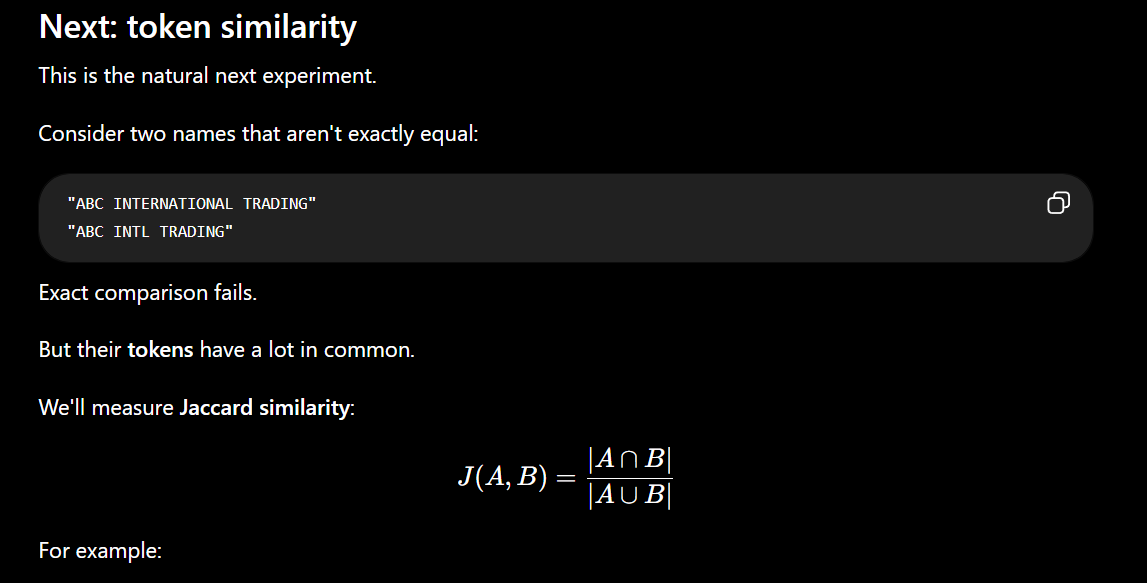

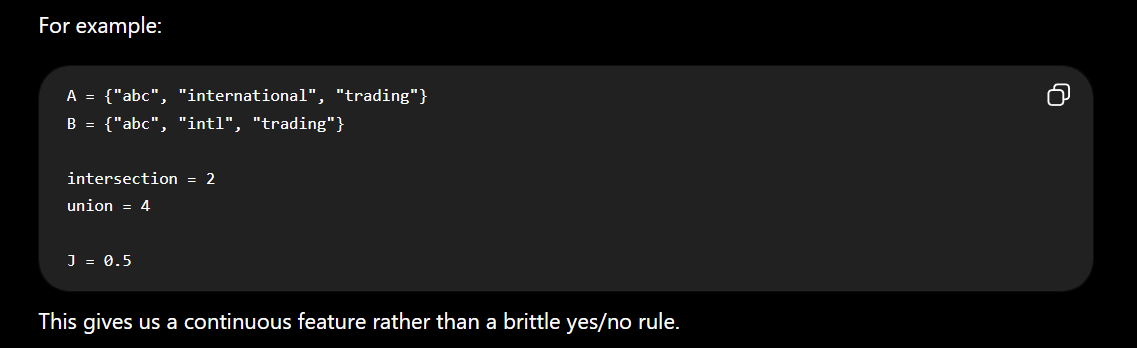

In [48]:
def token_jaccard(a, b):
    if not a or not b:
        return 0.0

    a_tokens = set(a.split())
    b_tokens = set(b.split())

    if not a_tokens or not b_tokens:
        return 0.0

    return len(a_tokens & b_tokens) / len(a_tokens | b_tokens)

In [49]:
dev_pairs = dev_pairs.with_columns(
    pl.struct(["name_legal", "matched_name_legal"])
    .map_elements(
        lambda x: token_jaccard(
            x["name_legal"],
            x["matched_name_legal"]
        ),
        return_dtype=pl.Float64
    )
    .alias("name_jaccard")
)

In [50]:
print(
    dev_pairs
    .select("name_jaccard")
    .describe()
)

shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ name_jaccard │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 27907.0      │
│ null_count ┆ 0.0          │
│ mean       ┆ 0.628078     │
│ std        ┆ 0.357993     │
│ min        ┆ 0.0          │
│ 25%        ┆ 0.333333     │
│ 50%        ┆ 0.666667     │
│ 75%        ┆ 1.0          │
│ max        ┆ 1.0          │
└────────────┴──────────────┘


In [51]:
print(
    dev_pairs
    .select(
        pl.col("name_jaccard")
        .quantile(0.01)
        .alias("p01"),

        pl.col("name_jaccard")
        .quantile(0.05)
        .alias("p05"),

        pl.col("name_jaccard")
        .quantile(0.10)
        .alias("p10"),

        pl.col("name_jaccard")
        .quantile(0.25)
        .alias("p25"),

        pl.col("name_jaccard")
        .quantile(0.50)
        .alias("median"),

        pl.col("name_jaccard")
        .quantile(0.75)
        .alias("p75"),

        pl.col("name_jaccard")
        .quantile(0.90)
        .alias("p90"),

        pl.col("name_jaccard")
        .quantile(0.95)
        .alias("p95"),

        pl.col("name_jaccard")
        .quantile(0.99)
        .alias("p99"),
    )
)

shape: (1, 9)
┌─────┬─────┬─────┬──────────┬───┬─────┬─────┬─────┬─────┐
│ p01 ┆ p05 ┆ p10 ┆ p25      ┆ … ┆ p75 ┆ p90 ┆ p95 ┆ p99 │
│ --- ┆ --- ┆ --- ┆ ---      ┆   ┆ --- ┆ --- ┆ --- ┆ --- │
│ f64 ┆ f64 ┆ f64 ┆ f64      ┆   ┆ f64 ┆ f64 ┆ f64 ┆ f64 │
╞═════╪═════╪═════╪══════════╪═══╪═════╪═════╪═════╪═════╡
│ 0.0 ┆ 0.0 ┆ 0.0 ┆ 0.333333 ┆ … ┆ 1.0 ┆ 1.0 ┆ 1.0 ┆ 1.0 │
└─────┴─────┴─────┴──────────┴───┴─────┴─────┴─────┴─────┘


In [52]:
# Next experiment: create negatives
s2_country_pool = (
    s2
    .select(["entity_id", "country"])
    .collect()
)

s3_country_pool = (
    s3
    .select(["entity_id", "country"])
    .collect()
)

print("S2 pool:", s2_country_pool.shape)
print("S3 pool:", s3_country_pool.shape)

print("\nS2 countries:")
print(
    s2_country_pool
    .group_by("country")
    .len()
    .sort("len", descending=True)
)

print("\nS3 countries:")
print(
    s3_country_pool
    .group_by("country")
    .len()
    .sort("len", descending=True)
)

S2 pool: (5034616, 2)
S3 pool: (5285603, 2)

S2 countries:
shape: (2, 2)
┌─────────┬─────────┐
│ country ┆ len     │
│ ---     ┆ ---     │
│ str     ┆ u32     │
╞═════════╪═════════╡
│ US      ┆ 3016817 │
│ India   ┆ 2017799 │
└─────────┴─────────┘

S3 countries:
shape: (2, 2)
┌─────────┬─────────┐
│ country ┆ len     │
│ ---     ┆ ---     │
│ str     ┆ u32     │
╞═════════╪═════════╡
│ US      ┆ 3170056 │
│ India   ┆ 2115547 │
└─────────┴─────────┘


In [53]:
# S1 records used in our development sample
s1_country = dev_s1_records.select([
    "entity_id",
    "country"
])

# All known TRUE S2 matches for each S1
true_s2 = (
    dev_matches
    .filter(pl.col("match_id").str.starts_with("S2-"))
    .group_by("source1_entity_id")
    .agg(
        pl.col("match_id").alias("true_s2_ids")
    )
)

# Join S1 with its true S2 IDs
s1_negative_pool = (
    s1_country
    .join(
        true_s2,
        left_on="entity_id",
        right_on="source1_entity_id",
        how="left"
    )
    .with_columns(
        pl.col("true_s2_ids")
        .fill_null([])
    )
)

print(s1_negative_pool.head())

shape: (5, 3)
┌──────────────┬─────────┬─────────────────────────────────┐
│ entity_id    ┆ country ┆ true_s2_ids                     │
│ ---          ┆ ---     ┆ ---                             │
│ str          ┆ str     ┆ list[str]                       │
╞══════════════╪═════════╪═════════════════════════════════╡
│ S1-387694500 ┆ India   ┆ ["S2-89272121", "S2-828925482"… │
│ S1-104226194 ┆ India   ┆ ["S2-162965740", "S2-482020390… │
│ S1-277159753 ┆ US      ┆ []                              │
│ S1-227546659 ┆ US      ┆ ["S2-546735803", "S2-500703675… │
│ S1-125472274 ┆ India   ┆ ["S2-673973171", "S2-218583667… │
└──────────────┴─────────┴─────────────────────────────────┘


In [54]:
s2_positive_pairs = (
    dev_matches
    .filter(pl.col("match_id").str.starts_with("S2-"))
)

print("Positive S2 pairs:", s2_positive_pairs.height)

print(
    s2_positive_pairs
    .join(
        dev_s1_records.select(["entity_id", "country"]),
        left_on="source1_entity_id",
        right_on="entity_id",
        how="left"
    )
    .group_by("country")
    .len()
)

Positive S2 pairs: 13420
shape: (2, 2)
┌─────────┬──────┐
│ country ┆ len  │
│ ---     ┆ ---  │
│ str     ┆ u32  │
╞═════════╪══════╡
│ India   ┆ 5351 │
│ US      ┆ 8069 │
└─────────┴──────┘


In [55]:
# Add country to every positive S2 pair
s2_neg_base = (
    s2_positive_pairs
    .join(
        dev_s1_records.select([
            "entity_id",
            "country"
        ]),
        left_on="source1_entity_id",
        right_on="entity_id",
        how="left"
    )
    .select([
        "source1_entity_id",
        "match_id",
        "country"
    ])
)

print("Negative pairs needed:", s2_neg_base.height)

Negative pairs needed: 13420


In [56]:
import math

negative_pools = []

for country in s2_neg_base["country"].unique().to_list():

    needed = s2_neg_base.filter(
        pl.col("country") == country
    ).height

    # Oversample so we have room after removing accidental true matches
    pool = (
        s2_country_pool
        .filter(pl.col("country") == country)
        .sample(
            n=min(
                needed * 2,
                s2_country_pool
                .filter(pl.col("country") == country)
                .height
            ),
            seed=42
        )
        .rename({
            "entity_id": "negative_id"
        })
    )

    negative_pools.append(pool)

negative_pool = pl.concat(negative_pools)

print("Candidate negative IDs:", negative_pool.height)

Candidate negative IDs: 26840


In [57]:
# Give each side a row number within country

negative_requests = (
    s2_neg_base
    .with_columns(
        pl.int_range(
            pl.len()
        ).over("country").alias("row_nr")
    )
)

negative_candidates = (
    negative_pool
    .with_columns(
        pl.int_range(
            pl.len()
        ).over("country").alias("row_nr")
    )
)

negative_candidates = (
    negative_requests
    .join(
        negative_candidates,
        on=["country", "row_nr"],
        how="left"
    )
)

print(negative_candidates.shape)
print(negative_candidates.head())

(13420, 5)
shape: (5, 5)
┌───────────────────┬──────────────┬─────────┬────────┬──────────────┐
│ source1_entity_id ┆ match_id     ┆ country ┆ row_nr ┆ negative_id  │
│ ---               ┆ ---          ┆ ---     ┆ ---    ┆ ---          │
│ str               ┆ str          ┆ str     ┆ i64    ┆ str          │
╞═══════════════════╪══════════════╪═════════╪════════╪══════════════╡
│ S1-221904005      ┆ S2-628386155 ┆ India   ┆ 0      ┆ S2-919664547 │
│ S1-445773636      ┆ S2-26331128  ┆ US      ┆ 0      ┆ S2-427831980 │
│ S1-138142441      ┆ S2-375257552 ┆ India   ┆ 1      ┆ S2-128983087 │
│ S1-442959231      ┆ S2-993233380 ┆ US      ┆ 1      ┆ S2-845662087 │
│ S1-352278537      ┆ S2-113578625 ┆ US      ┆ 2      ┆ S2-949252493 │
└───────────────────┴──────────────┴─────────┴────────┴──────────────┘


In [58]:
# Baseline 1
def basic_name_expr(column):
    return (
        pl.col(column)
        .fill_null("")
        .str.to_lowercase()
        .str.replace_all(r"[^\p{L}\p{N}\s]", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
    )


dev_s1_baseline = (
    dev_s1_records
    .with_columns(
        basic_name_expr("business_name").alias("name_basic")
    )
    .with_columns(
        (
            pl.col("country")
            + "||"
            + pl.col("name_basic")
        ).alias("match_key")
    )
)

baseline_keys = (
    dev_s1_baseline["match_key"]
    .unique()
    .to_list()
)

print("Development S1:", dev_s1_baseline.height)
print("Unique baseline keys:", len(baseline_keys))

Development S1: 5537
Unique baseline keys: 5479


In [59]:
s2_baseline_candidates = (
    s2
    .with_columns(
        basic_name_expr("business_name").alias("name_basic")
    )
    .with_columns(
        (
            pl.col("country")
            + "||"
            + pl.col("name_basic")
        ).alias("match_key")
    )
    .filter(
        pl.col("match_key").is_in(baseline_keys)
    )
    .select([
        "entity_id",
        "business_name",
        "business_address",
        "country",
        "match_key"
    ])
    .collect()
)

print("S2 baseline candidates:", s2_baseline_candidates.height)

S2 baseline candidates: 25303


In [60]:
s3_baseline_candidates = (
    s3
    .with_columns(
        basic_name_expr("business_name").alias("name_basic")
    )
    .with_columns(
        (
            pl.col("country")
            + "||"
            + pl.col("name_basic")
        ).alias("match_key")
    )
    .filter(
        pl.col("match_key").is_in(baseline_keys)
    )
    .select([
        "entity_id",
        "business_name",
        "business_address",
        "country",
        "match_key"
    ])
    .collect()
)

print("S3 baseline candidates:", s3_baseline_candidates.height)

S3 baseline candidates: 27939


In [61]:
# convert those candidates into predictions
baseline_s2_predictions = (
    dev_s1_baseline
    .select([
        "entity_id",
        "match_key"
    ])
    .join(
        s2_baseline_candidates.select([
            "entity_id",
            "match_key"
        ]),
        on="match_key",
        how="inner",
        suffix="_s2"
    )
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s2").alias("matched_entity_id")
    ])
)

In [62]:
baseline_s3_predictions = (
    dev_s1_baseline
    .select([
        "entity_id",
        "match_key"
    ])
    .join(
        s3_baseline_candidates.select([
            "entity_id",
            "match_key"
        ]),
        on="match_key",
        how="inner",
        suffix="_s3"
    )
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s3").alias("matched_entity_id")
    ])
)

In [63]:
baseline_predictions = pl.concat([
    baseline_s2_predictions,
    baseline_s3_predictions
])

print("Total baseline predictions:", baseline_predictions.height)
print("S2:", baseline_s2_predictions.height)
print("S3:", baseline_s3_predictions.height)

Total baseline predictions: 57467
S2: 27372
S3: 30095


In [64]:
# scoring it
true_pairs = (
    dev_matches
    .select([
        "source1_entity_id",
        pl.col("match_id").alias("matched_entity_id")
    ])
    .unique()
)

pred_pairs = baseline_predictions.unique()

print("True pairs:", true_pairs.height)
print("Predicted pairs:", pred_pairs.height)

True pairs: 27907
Predicted pairs: 57467


In [65]:
true_positive = (
    pred_pairs
    .join(
        true_pairs,
        on=["source1_entity_id", "matched_entity_id"],
        how="inner"
    )
    .height
)

false_positive = pred_pairs.height - true_positive

false_negative = true_pairs.height - true_positive

print("TP:", true_positive)
print("FP:", false_positive)
print("FN:", false_negative)

TP: 6056
FP: 51411
FN: 21851


In [66]:
precision = (
    true_positive /
    (true_positive + false_positive)
    if (true_positive + false_positive) > 0
    else 0
)

recall = (
    true_positive /
    (true_positive + false_negative)
    if (true_positive + false_negative) > 0
    else 0
)

f05 = (
    1.25 * precision * recall /
    (0.25 * precision + recall)
    if (0.25 * precision + recall) > 0
    else 0
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F0.5:      {f05:.4f}")

Precision: 0.1054
Recall:    0.2170
F0.5:      0.1175


In [67]:
def f05_score(tp, fp, fn):
    """
    F0.5 for one Source 1 entity.
    """
    if tp == 0:
        # No predicted matches and no true matches = perfect
        if fp == 0 and fn == 0:
            return 1.0
        return 0.0

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    if precision == 0 and recall == 0:
        return 0.0

    return (
        1.25 * precision * recall
        / (0.25 * precision + recall)
    )

In [68]:
# All development S1 entities
all_s1 = dev_s1_records.select(
    pl.col("entity_id").alias("source1_entity_id")
)

# TRUE pairs
true_by_s1 = (
    true_pairs
    .group_by("source1_entity_id")
    .agg(
        pl.col("matched_entity_id")
        .alias("true_ids")
    )
)

# PREDICTED pairs
pred_by_s1 = (
    pred_pairs
    .group_by("source1_entity_id")
    .agg(
        pl.col("matched_entity_id")
        .alias("pred_ids")
    )
)

# Bring both onto every S1
evaluation = (
    all_s1
    .join(true_by_s1, on="source1_entity_id", how="left")
    .join(pred_by_s1, on="source1_entity_id", how="left")
    .with_columns([
        pl.col("true_ids").fill_null([]),
        pl.col("pred_ids").fill_null([])
    ])
)

print(evaluation.shape)

(5537, 3)


In [69]:
evaluation = evaluation.with_columns([
    pl.col("pred_ids")
      .list.set_intersection(pl.col("true_ids"))
      .list.len()
      .alias("tp"),

    pl.col("pred_ids")
      .list.set_difference(pl.col("true_ids"))
      .list.len()
      .alias("fp"),

    pl.col("true_ids")
      .list.set_difference(pl.col("pred_ids"))
      .list.len()
      .alias("fn"),
])

In [70]:
evaluation = evaluation.with_columns(
    pl.struct(["tp", "fp", "fn"])
    .map_elements(
        lambda x: f05_score(
            x["tp"],
            x["fp"],
            x["fn"]
        ),
        return_dtype=pl.Float64
    )
    .alias("f05")
)

macro_f05 = evaluation["f05"].mean()

print(f"Macro F0.5: {macro_f05:.6f}")

Macro F0.5: 0.353042


In [71]:
print(
    evaluation
    .select("f05")
    .describe()
)

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ f05      │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 5537.0   │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.353042 │
│ std        ┆ 0.350386 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.0      │
│ 50%        ┆ 0.333333 │
│ 75%        ┆ 0.666667 │
│ max        ┆ 1.0      │
└────────────┴──────────┘


In [72]:
print(
    evaluation
    .filter(
        pl.col("true_ids").list.len() == 0
    )
    .select([
        "tp",
        "fp",
        "fn",
        "f05"
    ])
    .group_by("f05")
    .len()
    .sort("f05")
)

shape: (2, 2)
┌─────┬─────┐
│ f05 ┆ len │
│ --- ┆ --- │
│ f64 ┆ u32 │
╞═════╪═════╡
│ 0.0 ┆ 208 │
│ 1.0 ┆ 292 │
└─────┴─────┘


### Baseline 0: F0.5 -> 0.353042

| Result     | S1 entities |
| ---------- | ----------: |
| F0.5 = 1.0 |     **292** |
| F0.5 = 0.0 |     **208** |

292/500 = 58.4% true singletons were correctly left empty

208/500 = 41%6 were falsely flaged with atleast one match


### Baseline 1: Same country + legal-suffix-normalized exact name

In [73]:
dev_s1_legal = (
    dev_s1_records
    .with_columns(
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal")
    )
    .with_columns(
        (
            pl.col("country")
            + "||"
            + pl.col("name_legal")
        ).alias("match_key")
    )
)

legal_keys = dev_s1_legal["match_key"].unique().to_list()

print("Unique legal-normalized keys:", len(legal_keys))

Unique legal-normalized keys: 5414


In [74]:
s2_legal_candidates = (
    s2
    .with_columns(
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal")
    )
    .with_columns(
        (
            pl.col("country")
            + "||"
            + pl.col("name_legal")
        ).alias("match_key")
    )
    .filter(
        pl.col("match_key").is_in(legal_keys)
    )
    .select([
        "entity_id",
        "match_key"
    ])
    .collect()
)

print("S2 legal candidates:", s2_legal_candidates.height)

S2 legal candidates: 65836


In [75]:
s3_legal_candidates = (
    s3
    .with_columns(
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal")
    )
    .with_columns(
        (
            pl.col("country")
            + "||"
            + pl.col("name_legal")
        ).alias("match_key")
    )
    .filter(
        pl.col("match_key").is_in(legal_keys)
    )
    .select([
        "entity_id",
        "match_key"
    ])
    .collect()
)

print("S3 legal candidates:", s3_legal_candidates.height)

S3 legal candidates: 72337


In [76]:
baseline1_s2 = (
    dev_s1_legal
    .select(["entity_id", "match_key"])
    .join(
        s2_legal_candidates,
        on="match_key",
        how="inner",
        suffix="_s2"
    )
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s2").alias("matched_entity_id")
    ])
)

baseline1_s3 = (
    dev_s1_legal
    .select(["entity_id", "match_key"])
    .join(
        s3_legal_candidates,
        on="match_key",
        how="inner",
        suffix="_s3"
    )
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s3").alias("matched_entity_id")
    ])
)

baseline1_predictions = pl.concat([
    baseline1_s2,
    baseline1_s3
]).unique()

print("Baseline 1 predictions:", baseline1_predictions.height)

Baseline 1 predictions: 162970


In [77]:
pred_pairs_b1 = baseline1_predictions

pred_by_s1_b1 = (
    pred_pairs_b1
    .group_by("source1_entity_id")
    .agg(
        pl.col("matched_entity_id").alias("pred_ids")
    )
)

evaluation_b1 = (
    all_s1
    .join(true_by_s1, on="source1_entity_id", how="left")
    .join(pred_by_s1_b1, on="source1_entity_id", how="left")
    .with_columns([
        pl.col("true_ids").fill_null([]),
        pl.col("pred_ids").fill_null([])
    ])
    .with_columns([
        pl.col("pred_ids")
        .list.set_intersection(pl.col("true_ids"))
        .list.len()
        .alias("tp"),

        pl.col("pred_ids")
        .list.set_difference(pl.col("true_ids"))
        .list.len()
        .alias("fp"),

        pl.col("true_ids")
        .list.set_difference(pl.col("pred_ids"))
        .list.len()
        .alias("fn")
    ])
    .with_columns(
        pl.struct(["tp", "fp", "fn"])
        .map_elements(
            lambda x: f05_score(
                x["tp"],
                x["fp"],
                x["fn"]
            ),
            return_dtype=pl.Float64
        )
        .alias("f05")
    )
)

macro_f05_b1 = evaluation_b1["f05"].mean()

print(f"Baseline 0 Macro F0.5: {macro_f05:.6f}")
print(f"Baseline 1 Macro F0.5: {macro_f05_b1:.6f}")

Baseline 0 Macro F0.5: 0.353042
Baseline 1 Macro F0.5: 0.401798


```
🏁 DEVELOPMENT SCOREBOARD

Baseline 0
Country
+ basic name normalization
────────────────────────
Macro F0.5 = 0.353042

Baseline 1
Country
+ basic normalization
+ legal suffix normalization
────────────────────────
Macro F0.5 = 0.401798
```

In [78]:
true_s2_pairs = (
    dev_matches
    .filter(
        pl.col("match_id").str.starts_with("S2-")
    )
    .select([
        "source1_entity_id",
        pl.col("match_id").alias("negative_id")
    ])
    .unique()
)

safe_negative_candidates = (
    negative_candidates
    .join(
        true_s2_pairs,
        on=["source1_entity_id", "negative_id"],
        how="anti"
    )
)

print("Original negatives:", negative_candidates.height)
print("Safe negatives:", safe_negative_candidates.height)
print(
    "Accidental true negatives:",
    negative_candidates.height
    - safe_negative_candidates.height
)

Original negatives: 13420
Safe negatives: 13420
Accidental true negatives: 0


In [79]:
safe_negative_ids = (
    safe_negative_candidates["negative_id"]
    .unique()
    .to_list()
)

dev_s2_negative_records = (
    s2
    .filter(
        pl.col("entity_id").is_in(safe_negative_ids)
    )
    .collect()
)

print("Negative S2 records:", dev_s2_negative_records.shape)

Negative S2 records: (13420, 4)


In [80]:
negative_pairs = (
    safe_negative_candidates
    .join(
        dev_s1_records,
        left_on="source1_entity_id",
        right_on="entity_id",
        how="left"
    )
    .join(
        dev_s2_negative_records,
        left_on="negative_id",
        right_on="entity_id",
        how="left",
        suffix="_negative"
    )
    .select([
        "source1_entity_id",
        "country",
        pl.col("business_name").alias("business_name"),
        pl.col("business_name_negative").alias("matched_name"),
        pl.col("business_address").alias("business_address"),
        pl.col("business_address_negative").alias("matched_address"),
        pl.lit(0).alias("label")
    ])
)

print("Negative pairs:", negative_pairs.height)

Negative pairs: 13420


In [81]:
positive_feature_pairs = (
    dev_pairs
    .select([
        "source1_entity_id",
        "country",
        "business_name",
        "matched_name",
        "business_address",
        "matched_address",
        pl.lit(1).alias("label")
    ])
)

print("Positive pairs:", positive_feature_pairs.height)

Positive pairs: 27907


In [82]:
negative_pairs = negative_pairs.with_columns([
    pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal"),

    pl.col("matched_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("matched_name_legal")
])

In [83]:
negative_pairs = negative_pairs.with_columns(
    pl.struct(["name_legal", "matched_name_legal"])
    .map_elements(
        lambda x: token_jaccard(
            x["name_legal"],
            x["matched_name_legal"]
        ),
        return_dtype=pl.Float64
    )
    .alias("name_jaccard")
)

In [84]:
positive_feature_pairs = positive_feature_pairs.with_columns([
    pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal"),

    pl.col("matched_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("matched_name_legal")
])

In [85]:
positive_feature_pairs = positive_feature_pairs.with_columns(
    pl.struct(["name_legal", "matched_name_legal"])
    .map_elements(
        lambda x: token_jaccard(
            x["name_legal"],
            x["matched_name_legal"]
        ),
        return_dtype=pl.Float64
    )
    .alias("name_jaccard")
)

In [86]:
print("===== TRUE PAIRS =====")

print(
    positive_feature_pairs
    .select("name_jaccard")
    .describe()
)

print("\n===== FALSE PAIRS =====")

print(
    negative_pairs
    .select("name_jaccard")
    .describe()
)

===== TRUE PAIRS =====
shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ name_jaccard │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 27907.0      │
│ null_count ┆ 0.0          │
│ mean       ┆ 0.628078     │
│ std        ┆ 0.357993     │
│ min        ┆ 0.0          │
│ 25%        ┆ 0.333333     │
│ 50%        ┆ 0.666667     │
│ 75%        ┆ 1.0          │
│ max        ┆ 1.0          │
└────────────┴──────────────┘

===== FALSE PAIRS =====
shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ name_jaccard │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 13420.0      │
│ null_count ┆ 0.0          │
│ mean       ┆ 0.002817     │
│ std        ┆ 0.024864     │
│ min        ┆ 0.0          │
│ 25%        ┆ 0.0          │
│ 50%        ┆ 0.0          │
│ 75%        ┆ 0.0          │
│ max        ┆ 0.666667     │
└────────────┴──────────────┘


In [87]:
def jaccard_percentiles(df):
    return df.select([
        pl.col("name_jaccard").quantile(0.01).alias("p01"),
        pl.col("name_jaccard").quantile(0.05).alias("p05"),
        pl.col("name_jaccard").quantile(0.10).alias("p10"),
        pl.col("name_jaccard").quantile(0.25).alias("p25"),
        pl.col("name_jaccard").quantile(0.50).alias("median"),
        pl.col("name_jaccard").quantile(0.75).alias("p75"),
        pl.col("name_jaccard").quantile(0.90).alias("p90"),
        pl.col("name_jaccard").quantile(0.95).alias("p95"),
        pl.col("name_jaccard").quantile(0.99).alias("p99"),
    ])

print("TRUE:")
print(jaccard_percentiles(positive_feature_pairs))

print("\nFALSE:")
print(jaccard_percentiles(negative_pairs))

TRUE:
shape: (1, 9)
┌─────┬─────┬─────┬──────────┬───┬─────┬─────┬─────┬─────┐
│ p01 ┆ p05 ┆ p10 ┆ p25      ┆ … ┆ p75 ┆ p90 ┆ p95 ┆ p99 │
│ --- ┆ --- ┆ --- ┆ ---      ┆   ┆ --- ┆ --- ┆ --- ┆ --- │
│ f64 ┆ f64 ┆ f64 ┆ f64      ┆   ┆ f64 ┆ f64 ┆ f64 ┆ f64 │
╞═════╪═════╪═════╪══════════╪═══╪═════╪═════╪═════╪═════╡
│ 0.0 ┆ 0.0 ┆ 0.0 ┆ 0.333333 ┆ … ┆ 1.0 ┆ 1.0 ┆ 1.0 ┆ 1.0 │
└─────┴─────┴─────┴──────────┴───┴─────┴─────┴─────┴─────┘

FALSE:
shape: (1, 9)
┌─────┬─────┬─────┬─────┬───┬─────┬─────┬─────┬──────────┐
│ p01 ┆ p05 ┆ p10 ┆ p25 ┆ … ┆ p75 ┆ p90 ┆ p95 ┆ p99      │
│ --- ┆ --- ┆ --- ┆ --- ┆   ┆ --- ┆ --- ┆ --- ┆ ---      │
│ f64 ┆ f64 ┆ f64 ┆ f64 ┆   ┆ f64 ┆ f64 ┆ f64 ┆ f64      │
╞═════╪═════╪═════╪═════╪═══╪═════╪═════╪═════╪══════════╡
│ 0.0 ┆ 0.0 ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.0 ┆ 0.0 ┆ 0.0 ┆ 0.142857 │
└─────┴─────┴─────┴─────┴───┴─────┴─────┴─────┴──────────┘


```
BASELINE 0
country + basic exact name
       │
       │ Macro F0.5
       ▼
     0.3530
       │
       ▼
BASELINE 1
country + legal-normalized exact name
       │
       ▼
     0.4018
       │
       ▼
FEATURE AUDIT
       │
       ├── legal suffix → useful
       │
       └── Jaccard → VERY promising
```

In [88]:
# perform a small threshold experiment on this TRUE/FALSE dataset purely to understand the feature.
thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for threshold in thresholds:
    tp = (
        positive_feature_pairs["name_jaccard"] >= threshold
    ).sum()

    fn = (
        positive_feature_pairs["name_jaccard"] < threshold
    ).sum()

    fp = (
        negative_pairs["name_jaccard"] >= threshold
    ).sum()

    tn = (
        negative_pairs["name_jaccard"] < threshold
    ).sum()

    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0

    f05 = (
        1.25 * precision * recall /
        (0.25 * precision + recall)
        if precision + recall > 0
        else 0
    )

    print(
        f"{threshold:.1f} | "
        f"TP={tp:5d} "
        f"FP={fp:5d} "
        f"Precision={precision:.3f} "
        f"Recall={recall:.3f} "
        f"F0.5={f05:.3f}"
    )

0.0 | TP=27907 FP=13420 Precision=0.675 Recall=1.000 F0.5=0.722
0.1 | TP=23905 FP=  190 Precision=0.992 Recall=0.857 F0.5=0.962
0.2 | TP=23790 FP=   93 Precision=0.996 Recall=0.852 F0.5=0.964
0.3 | TP=22623 FP=   19 Precision=0.999 Recall=0.811 F0.5=0.955
0.4 | TP=20323 FP=    1 Precision=1.000 Recall=0.728 F0.5=0.931
0.5 | TP=19582 FP=    1 Precision=1.000 Recall=0.702 F0.5=0.922
0.6 | TP=16484 FP=    1 Precision=1.000 Recall=0.591 F0.5=0.878
0.7 | TP=12297 FP=    0 Precision=1.000 Recall=0.441 F0.5=0.798
0.8 | TP=10994 FP=    0 Precision=1.000 Recall=0.394 F0.5=0.765
0.9 | TP=10629 FP=    0 Precision=1.000 Recall=0.381 F0.5=0.755
1.0 | TP=10629 FP=    0 Precision=1.000 Recall=0.381 F0.5=0.755


                         DEVELOPMENT
                              │
                 ┌────────────┴────────────┐
                 ▼                         ▼
             BASELINES               FEATURE STUDY
                 │                         │
       B0 = 0.3530 F0.5              Jaccard
                 │                         │
       B1 = 0.4018 F0.5              TRUE vs FALSE
                                           │
                                           ▼
                                  Extremely strong
                                  against easy negatives

### Next: Hard Negatives
> Instead of randomly choosing S2 records, we're going to deliberately find same-country S2 records whose names have high Jaccard with an S1 but are NOT ground-truth matches.

Something like:
```
S1                    S2
──────────────────────────────────
ABC TECHNOLOGIES       ABC TECHNOLOGY
ABC TECHNOLOGIES       ABC TECHNOLOGIES INDIA
ABC TRADERS            ABC TRADING
```
If the results are something like:
```
                 TRUE       HARD FALSE

median           0.667         0.333
p75              1.000         0.667
p90              1.000         1.000

```
The jaccard alone cannot distinguish the difficult cases.


#### Goal: Find S2 businesses that look similar by name to an S1, but are known non-matches.

In [89]:
# Step 1: Create a compact name-block key
## ignoring common legal names -> ltd, pvt, lc, corp...
LEGAL_WORDS = {
    "ltd", "limited",
    "pvt", "private",
    "llc",
    "inc", "incorporated",
    "corp", "corporation",
    "co", "company",
    "plc"
}

def first_informative_token(text):
    if not text:
        return ""

    tokens = text.split()

    for token in tokens:
        token = token.strip()
        if (
            len(token) >= 3
            and token not in LEGAL_WORDS
        ):
            return token

    return ""


dev_s1_hard = (
    dev_s1_records
    .with_columns(
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal")
    )
    .with_columns(
        pl.col("name_legal")
        .map_elements(
            first_informative_token,
            return_dtype=pl.String
        )
        .alias("name_block")
    )
)

print(
    dev_s1_hard
    .select("name_block")
    .describe()
)

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ name_block │
│ ---        ┆ ---        │
│ str        ┆ str        │
╞════════════╪════════════╡
│ count      ┆ 5537       │
│ null_count ┆ 0          │
│ mean       ┆ null       │
│ std        ┆ null       │
│ min        ┆            │
│ 25%        ┆ null       │
│ 50%        ┆ null       │
│ 75%        ┆ null       │
│ max        ┆ zsr        │
└────────────┴────────────┘


In [90]:
# Step 2: See how common these blocks are in S2
## calculating the frequency of the s1 block tokens in s2
s1_blocks = (
    dev_s1_hard
    .select("name_block")
    .filter(
        pl.col("name_block") != ""
    )
    .unique()
    .to_series()
    .to_list()
)

print("Unique S1 block tokens:", len(s1_blocks))

Unique S1 block tokens: 2877


In [91]:
# scanning s2
s2_block_counts = (
    s2
    .with_columns(
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal")
    )
    .with_columns(
        pl.col("name_legal")
        .map_elements(
            first_informative_token,
            return_dtype=pl.String
        )
        .alias("name_block")
    )
    .filter(
        pl.col("name_block").is_in(s1_blocks)
    )
    .group_by("name_block")
    .len()
    .sort("len", descending=True)
    .collect()
)

print(s2_block_counts.head(20))

shape: (20, 2)
┌────────────┬───────┐
│ name_block ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ the        ┆ 42563 │
│ pediatric  ┆ 30635 │
│ services   ┆ 17555 │
│ new        ┆ 16770 │
│ india      ┆ 14696 │
│ …          ┆ …     │
│ ear        ┆ 10437 │
│ dental     ┆ 10432 │
│ mumbai     ┆ 10369 │
│ foot       ┆ 10344 │
│ primary    ┆ 10308 │
└────────────┴───────┘


In [92]:
# calculate how frequently individual tokens occur in S2

# Build token frequencies in S2
s2_token_freq = (
    s2
    .with_columns(
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal")
    )
    .with_columns(
        pl.col("name_legal")
        .str.split(" ")
        .alias("tokens")
    )
    .explode("tokens")
    .filter(
        (pl.col("tokens") != "") &
        (pl.col("tokens").str.len_chars() >= 3)
    )
    .group_by("tokens")
    .len()
    .sort("len", descending=True)
    .collect()
)

print(s2_token_freq.head(30))

C:\Users\abhil\AppData\Local\Temp\ipykernel_43836\1527267644.py:20: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("tokens")


shape: (30, 2)
┌───────────┬────────┐
│ tokens    ┆ len    │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ private   ┆ 224718 │
│ com       ┆ 202135 │
│ center    ┆ 196536 │
│ partners  ┆ 155487 │
│ services  ┆ 147339 │
│ …         ┆ …      │
│ global    ┆ 35629  │
│ brothers  ┆ 35484  │
│ trading   ┆ 35372  │
│ pediatric ┆ 33306  │
│ medicine  ┆ 31781  │
└───────────┴────────┘


In [93]:
print(
    s2_token_freq
    .sort("len")
    .head(30)
)

shape: (30, 2)
┌───────────────┬─────┐
│ tokens        ┆ len │
│ ---           ┆ --- │
│ str           ┆ u32 │
╞═══════════════╪═════╡
│ laonnaa       ┆ 1   │
│ 4828641452    ┆ 1   │
│ gólbtl        ┆ 1   │
│ tqwtextiles   ┆ 1   │
│ enrhnet       ┆ 1   │
│ …             ┆ …   │
│ píivtnie      ┆ 1   │
│ ktesre        ┆ 1   │
│ fergusongroup ┆ 1   │
│ tsrnasirt     ┆ 1   │
│ taauttd       ┆ 1   │
└───────────────┴─────┘


In [94]:
rare_tokens = (
    s2_token_freq
    .filter(
        pl.col("len") <= 500
    )
    .select("tokens")
    .to_series()
    .to_list()
)

s1_with_rare_token = (
    dev_s1_hard
    .with_columns(
        pl.col("name_legal")
        .str.split(" ")
        .alias("tokens")
    )
    .with_columns(
        pl.col("tokens")
        .list.eval(
            pl.element().is_in(rare_tokens)
        )
        .list.any()
        .alias("has_rare_token")
    )
)

print(
    s1_with_rare_token
    .group_by("has_rare_token")
    .len()
)

shape: (2, 2)
┌────────────────┬──────┐
│ has_rare_token ┆ len  │
│ ---            ┆ ---  │
│ bool           ┆ u32  │
╞════════════════╪══════╡
│ true           ┆ 2484 │
│ false          ┆ 3053 │
└────────────────┴──────┘


In [95]:
# Rare-token-only blocking at 500 is unacceptable for the final system.

Rather than guessing whether 500 is too restrictive, let's measure the tradeoff.

```

Token frequency threshold
        ↓
How many S1s can use it?
        ↓
How many TRUE pairs survive it?
```
That will gives actual blocking evidence.

In [96]:
thresholds = [100, 500, 1000, 5000, 10000, 50000]

# Convert frequency table to a Python dictionary
token_freq_dict = dict(
    zip(
        s2_token_freq["tokens"].to_list(),
        s2_token_freq["len"].to_list()
    )
)

for threshold in thresholds:

    rare_set = {
        token
        for token, freq in token_freq_dict.items()
        if freq <= threshold
    }

    # S1 coverage
    s1_coverage = (
        dev_s1_hard
        .with_columns(
            pl.col("name_legal")
            .str.split(" ")
            .list.eval(
                pl.element().is_in(list(rare_set))
            )
            .list.any()
            .alias("has_rare")
        )
        ["has_rare"]
        .sum()
    )

    # TRUE-pair coverage
    positive_tokens = (
        dev_pairs
        .select([
            "name_legal",
            "matched_name_legal"
        ])
        .with_columns([
            pl.col("name_legal")
            .fill_null("")
            .str.split(" ")
            .alias("s1_tokens"),

            pl.col("matched_name_legal")
            .fill_null("")
            .str.split(" ")
            .alias("s2_tokens")
        ])
        .with_columns(
            pl.concat_list([
                pl.col("s1_tokens"),
                pl.col("s2_tokens")
            ])
            .alias("all_tokens")
        )
    )

    # A TRUE pair survives if it has at least
    # one token from the rare-token vocabulary.
    pair_coverage = (
        positive_tokens
        .with_columns(
            pl.col("all_tokens")
            .list.eval(
                pl.element().is_in(list(rare_set))
            )
            .list.any()
            .alias("survives")
        )["survives"]
        .mean()
    )

    print(
        f"<= {threshold:5d} | "
        f"S1 coverage: {s1_coverage:4d}/{dev_s1_hard.height} "
        f"({s1_coverage/dev_s1_hard.height:.2%}) | "
        f"TRUE-pair token coverage: {pair_coverage:.2%}"
    )

<=   100 | S1 coverage: 1794/5537 (32.40%) | TRUE-pair token coverage: 43.94%
<=   500 | S1 coverage: 2484/5537 (44.86%) | TRUE-pair token coverage: 56.40%
<=  1000 | S1 coverage: 3064/5537 (55.34%) | TRUE-pair token coverage: 65.22%
<=  5000 | S1 coverage: 4336/5537 (78.31%) | TRUE-pair token coverage: 83.61%
<= 10000 | S1 coverage: 4797/5537 (86.64%) | TRUE-pair token coverage: 90.07%
<= 50000 | S1 coverage: 5523/5537 (99.75%) | TRUE-pair token coverage: 99.88%


Notice:
```
10,000 → 90.07% true-pair coverage
50,000 → 99.88%
```
That's a massive jump.

It tells us that many genuine business names don't contain genuinely rare tokens. Their useful identifying tokens can actually be fairly common.

For example, something like:
```
medical
services
center
```
might occur thousands of times but still provide useful candidate-generation information when combined with another key.

So our eventual blocking strategy should probably use combinations, not one token.

We now know:
```
Blocking pass 1
```
- Exact normalized/legal name

Very precise, but misses lots of matches.
```
Blocking pass 2
```
- Rare-token based

Can achieve very high recall, but becomes increasingly broad as the frequency threshold rises.

We want a Multi-Pass blcoker
```
                    S1
                     │
       ┌─────────────┼──────────────┐
       ▼             ▼              ▼
   exact name    token blocking   address
       │             │              │
       ▼             ▼              ▼
    precise       high recall     independent
       │             │              │
       └─────────────┼──────────────┘
                     ▼
                   UNION
                     │
                     ▼
              final candidates

For the same 13,420 TRUE vs 13,420 FALSE pairs, calculate address similarity and see whether it rescues cases where name similarity fails.

### Moving from name reconnaissance → address reconnaissance.

In [97]:
print("TRUE address null/empty:")

print(
    positive_feature_pairs
    .select(
        (
            pl.col("business_address")
            .fill_null("")
            .str.strip_chars()
            == ""
        )
        .sum()
        .alias("empty")
    )
)

print("\nFALSE address null/empty:")

print(
    negative_pairs
    .select(
        (
            pl.col("business_address")
            .fill_null("")
            .str.strip_chars()
            == ""
        )
        .sum()
        .alias("empty")
    )
)

TRUE address null/empty:
shape: (1, 1)
┌───────┐
│ empty │
│ ---   │
│ u32   │
╞═══════╡
│ 0     │
└───────┘

FALSE address null/empty:
shape: (1, 1)
┌───────┐
│ empty │
│ ---   │
│ u32   │
╞═══════╡
│ 0     │
└───────┘


In [98]:
print("===== TRUE PAIRS =====")

print(
    positive_feature_pairs
    .select(
        (
            pl.col("business_address")
            .fill_null("")
            .str.strip_chars()
            == ""
        )
        .sum()
        .alias("empty_address")
    )
)

print("\n===== FALSE PAIRS =====")

print(
    negative_pairs
    .select(
        (
            pl.col("business_address")
            .fill_null("")
            .str.strip_chars()
            == ""
        )
        .sum()
        .alias("empty_address")
    )
)

===== TRUE PAIRS =====
shape: (1, 1)
┌───────────────┐
│ empty_address │
│ ---           │
│ u32           │
╞═══════════════╡
│ 0             │
└───────────────┘

===== FALSE PAIRS =====
shape: (1, 1)
┌───────────────┐
│ empty_address │
│ ---           │
│ u32           │
╞═══════════════╡
│ 0             │
└───────────────┘


In [99]:
# address is available for every pair in our current development set.

In [100]:
### Build normalized address Jaccard

In [101]:
def normalize_address(expr):
    return (
        expr
        .fill_null("")
        .str.to_lowercase()
        .str.replace_all(r"[^a-z0-9\s]", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
    )


positive_feature_pairs = positive_feature_pairs.with_columns([
    normalize_address(pl.col("business_address"))
        .alias("address_norm"),

    normalize_address(pl.col("matched_address"))
        .alias("matched_address_norm"),
])

negative_pairs = negative_pairs.with_columns([
    normalize_address(pl.col("business_address"))
        .alias("address_norm"),

    normalize_address(pl.col("matched_address"))
        .alias("matched_address_norm"),
])

In [102]:
positive_feature_pairs = positive_feature_pairs.with_columns(
    pl.struct(["address_norm", "matched_address_norm"])
    .map_elements(
        lambda x: token_jaccard(
            x["address_norm"],
            x["matched_address_norm"]
        ),
        return_dtype=pl.Float64
    )
    .alias("address_jaccard")
)

negative_pairs = negative_pairs.with_columns(
    pl.struct(["address_norm", "matched_address_norm"])
    .map_elements(
        lambda x: token_jaccard(
            x["address_norm"],
            x["matched_address_norm"]
        ),
        return_dtype=pl.Float64
    )
    .alias("address_jaccard")
)

In [103]:
print("===== TRUE PAIRS =====")
print(
    positive_feature_pairs
    .select("address_jaccard")
    .describe()
)

print("\n===== FALSE PAIRS =====")
print(
    negative_pairs
    .select("address_jaccard")
    .describe()
)

===== TRUE PAIRS =====
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ address_jaccard │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 27907.0         │
│ null_count ┆ 0.0             │
│ mean       ┆ 0.614156        │
│ std        ┆ 0.269366        │
│ min        ┆ 0.0             │
│ 25%        ┆ 0.428571        │
│ 50%        ┆ 0.666667        │
│ 75%        ┆ 0.833333        │
│ max        ┆ 1.0             │
└────────────┴─────────────────┘

===== FALSE PAIRS =====
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ address_jaccard │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 13420.0         │
│ null_count ┆ 0.0             │
│ mean       ┆ 0.016906        │
│ std        ┆ 0.036181        │
│ min        ┆ 0.0             │
│ 25%        ┆ 0.0             │
│ 50%        ┆ 0.0             │
│ 75%        ┆ 0.0             │


In [104]:
# Address Jaccard is clearly separating TRUE and FALSE pairs
# 75% of TRUE pairs have address Jaccard ≥ 0.4286, while 75% of FALSE pairs are exactly 0.

### Next experiment: address-only threshold sweep

In [105]:
def evaluate_address_threshold(threshold):
    y_true = (
        [1] * positive_feature_pairs.height
        + [0] * negative_pairs.height
    )

    scores = (
        positive_feature_pairs["address_jaccard"].to_list()
        + negative_pairs["address_jaccard"].to_list()
    )

    y_pred = [int(x >= threshold) for x in scores]

    tp = sum(y == 1 and p == 1 for y, p in zip(y_true, y_pred))
    fp = sum(y == 0 and p == 1 for y, p in zip(y_true, y_pred))
    fn = sum(y == 1 and p == 0 for y, p in zip(y_true, y_pred))

    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0

    f05 = (
        1.25 * precision * recall /
        (0.25 * precision + recall)
        if precision + recall > 0 else 0
    )

    return tp, fp, precision, recall, f05

In [106]:
for threshold in [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7, 0.8]:
    tp, fp, precision, recall, f05 = evaluate_address_threshold(threshold)

    print(
        f"{threshold:.2f} "
        f"TP={tp:5d} "
        f"FP={fp:4d} "
        f"Precision={precision:.3f} "
        f"Recall={recall:.3f} "
        f"F0.5={f05:.3f}"
    )

0.00 TP=27907 FP=13420 Precision=0.675 Recall=1.000 F0.5=0.722
0.05 TP=26626 FP=2043 Precision=0.929 Recall=0.954 F0.5=0.934
0.10 TP=26581 FP= 787 Precision=0.971 Recall=0.952 F0.5=0.967
0.15 TP=26408 FP= 130 Precision=0.995 Recall=0.946 F0.5=0.985
0.20 TP=26138 FP=  56 Precision=0.998 Recall=0.937 F0.5=0.985
0.25 TP=25529 FP=  14 Precision=0.999 Recall=0.915 F0.5=0.981
0.30 TP=24474 FP=   1 Precision=1.000 Recall=0.877 F0.5=0.973
0.35 TP=23263 FP=   1 Precision=1.000 Recall=0.834 F0.5=0.962
0.40 TP=22124 FP=   0 Precision=1.000 Recall=0.793 F0.5=0.950
0.50 TP=19116 FP=   0 Precision=1.000 Recall=0.685 F0.5=0.916
0.60 TP=15551 FP=   0 Precision=1.000 Recall=0.557 F0.5=0.863
0.70 TP=11678 FP=   0 Precision=1.000 Recall=0.418 F0.5=0.783
0.80 TP= 7999 FP=   0 Precision=1.000 Recall=0.287 F0.5=0.668


Name Jaccard

True pairs:
```
mean ≈ 0.628
```
False pairs:
```
mean ≈ 0.003
```
And name threshold 0.1 gave approximately:
```
Precision ≈ 0.999
Recall    ≈ 0.852
F0.5      ≈ 0.962
```
Address Jaccard
At 0.15:
```
Precision ≈ 0.995
Recall    ≈ 0.946
F0.5      ≈ 0.987
```
2 extremely useful but imperfect signals.

### What happens when we put them together?

need to find out whether:
```
Name weak + Address strong
```
and
```
Name strong + Address weak
```
contain genuine matches.

Because if they do, a model can exploit the complementarity.
```
                 Address
               weak    strong
            ┌────────┬────────┐
Name weak   │   ?    │   TRUE │
            ├────────┼────────┤
Name strong │  TRUE  │  TRUE  │
            └────────┴────────┘

```


### Next experiment: 2D evidence

In [107]:
print("===== TRUE PAIRS =====")

print(
    positive_feature_pairs
    .select([
        "name_jaccard",
        "address_jaccard"
    ])
    .describe()
)

print("\n===== FALSE PAIRS =====")

print(
    negative_pairs
    .select([
        "name_jaccard",
        "address_jaccard"
    ])
    .describe()
)

===== TRUE PAIRS =====
shape: (9, 3)
┌────────────┬──────────────┬─────────────────┐
│ statistic  ┆ name_jaccard ┆ address_jaccard │
│ ---        ┆ ---          ┆ ---             │
│ str        ┆ f64          ┆ f64             │
╞════════════╪══════════════╪═════════════════╡
│ count      ┆ 27907.0      ┆ 27907.0         │
│ null_count ┆ 0.0          ┆ 0.0             │
│ mean       ┆ 0.628078     ┆ 0.614156        │
│ std        ┆ 0.357993     ┆ 0.269366        │
│ min        ┆ 0.0          ┆ 0.0             │
│ 25%        ┆ 0.333333     ┆ 0.428571        │
│ 50%        ┆ 0.666667     ┆ 0.666667        │
│ 75%        ┆ 1.0          ┆ 0.833333        │
│ max        ┆ 1.0          ┆ 1.0             │
└────────────┴──────────────┴─────────────────┘

===== FALSE PAIRS =====
shape: (9, 3)
┌────────────┬──────────────┬─────────────────┐
│ statistic  ┆ name_jaccard ┆ address_jaccard │
│ ---        ┆ ---          ┆ ---             │
│ str        ┆ f64          ┆ f64             │
╞═══════════

TRUE pairs

```
Name Jaccard mean: 0.628
Address Jaccard mean: 0.614
Both have median around 0.667
Both reach 1.0
```
FALSE pairs
```
Name Jaccard mean: 0.0028
Address Jaccard mean: 0.0169
Both have median 0
Address max: 0.375
Name max: 0.667
```
Q-> Are there true matches where one signal is weak but the other is strong?

In [108]:
def evidence_bucket(df):
    return (
        df.with_columns([
            (pl.col("name_jaccard") >= 0.1).alias("name_strong"),
            (pl.col("address_jaccard") >= 0.15).alias("address_strong"),
        ])
        .group_by(["name_strong", "address_strong"])
        .len()
        .sort(["name_strong", "address_strong"])
    )

print("===== TRUE PAIRS =====")
print(evidence_bucket(positive_feature_pairs))

print("\n===== FALSE PAIRS =====")
print(evidence_bucket(negative_pairs))

===== TRUE PAIRS =====
shape: (4, 3)
┌─────────────┬────────────────┬───────┐
│ name_strong ┆ address_strong ┆ len   │
│ ---         ┆ ---            ┆ ---   │
│ bool        ┆ bool           ┆ u32   │
╞═════════════╪════════════════╪═══════╡
│ false       ┆ false          ┆ 47    │
│ false       ┆ true           ┆ 3955  │
│ true        ┆ false          ┆ 1452  │
│ true        ┆ true           ┆ 22453 │
└─────────────┴────────────────┴───────┘

===== FALSE PAIRS =====
shape: (4, 3)
┌─────────────┬────────────────┬───────┐
│ name_strong ┆ address_strong ┆ len   │
│ ---         ┆ ---            ┆ ---   │
│ bool        ┆ bool           ┆ u32   │
╞═════════════╪════════════════╪═══════╡
│ false       ┆ false          ┆ 13101 │
│ false       ┆ true           ┆ 129   │
│ true        ┆ false          ┆ 189   │
│ true        ┆ true           ┆ 1     │
└─────────────┴────────────────┴───────┘


```
strong + strong region:

TRUE: ~22.4k
FALSE: 1
```
extraordinarily clean region.

cross-signal cases:

Address rescues weak names
```
Name weak + Address strong

TRUE  ≈ 3,995
FALSE ≈ 129
```
There are thousands of genuine matches that a name-only system could miss.

Name rescues weak addresses
```
Name strong + Address weak

TRUE  ≈ 1,452
FALSE ≈ 189
```
Name provides useful complementary evidence.

```
weak/weak region
TRUE  ≈ 47
FALSE ≈ 13,101
```
That's exactly what we'd expect.

This suggests a very natural matching architecture:
```
                 Candidate Pair
                       │
             ┌─────────┴─────────┐
             ▼                   ▼
       NAME EVIDENCE        ADDRESS EVIDENCE
             │                   │
             ▼                   ▼
        name_jaccard        address_jaccard
             │                   │
             └─────────┬─────────┘
                       ▼
                 MATCH DECISION
```

### For every true match in development ground truth, can the blocking strategy actually retrieve the matching S2/S3 record?

In [109]:
# ============================================
# BLOCKING EXPERIMENT 1: NAME-BASED BLOCKS
# ============================================

def add_blocking_fields(df):
    return df.with_columns([
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_basic,
            return_dtype=pl.String
        )
        .alias("name_basic"),

        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal"),
    ])


dev_s1_block = add_blocking_fields(dev_s1_records)

s2_block = (
    s2
    .select(["entity_id", "business_name", "business_address", "country"])
    .with_columns([
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_basic,
            return_dtype=pl.String
        )
        .alias("name_basic"),

        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal"),
    ])
)

print("S1:", dev_s1_block.height)

S1: 5537


In [110]:
# ============================================
# EXACT NORMALIZED-NAME BLOCK
# ============================================

name_block_candidates = (
    dev_s1_block
    .lazy()
    .select([
        "entity_id",
        "name_basic"
    ])
    .join(
        s2_block.select([
            "entity_id",
            "name_basic"
        ]),
        on="name_basic",
        how="inner",
        suffix="_s2"
    )
)

# First: DON'T collect all candidates yet.
candidate_count = (
    name_block_candidates
    .select(pl.len().alias("candidate_pairs"))
    .collect()
)

print(candidate_count)

shape: (1, 1)
┌─────────────────┐
│ candidate_pairs │
│ ---             │
│ u32             │
╞═════════════════╡
│ 27423           │
└─────────────────┘


In [111]:
# ============================================
# MEASURE TRUE-PAIR COVERAGE
# ============================================

name_block_keys = (
    name_block_candidates
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s2").alias("matched_entity_id")
    ])
    .unique()
    .collect()
)

covered_true = (
    true_pairs
    .join(
        name_block_keys,
        on=["source1_entity_id", "matched_entity_id"],
        how="inner"
    )
)

print("TRUE pairs:", true_pairs.height)
print("Recovered by name block:", covered_true.height)
print(
    "Blocking recall:",
    covered_true.height / true_pairs.height
)

TRUE pairs: 27907
Recovered by name block: 2866
Blocking recall: 0.1026982477514602


In [112]:
# ============================================
# S2 TRUE PAIRS ONLY
# ============================================

true_s2_pairs = (
    true_pairs
    .filter(
        pl.col("matched_entity_id").str.starts_with("S2-")
    )
)

print("Total S2 TRUE pairs:", true_s2_pairs.height)

Total S2 TRUE pairs: 13420


In [113]:
covered_true_s2 = (
    true_s2_pairs
    .join(
        name_block_keys,
        on=["source1_entity_id", "matched_entity_id"],
        how="inner"
    )
)

print("S2 TRUE pairs:", true_s2_pairs.height)
print("Recovered by name block:", covered_true_s2.height)

print(
    "S2 blocking recall:",
    covered_true_s2.height / true_s2_pairs.height
)

S2 TRUE pairs: 13420
Recovered by name block: 2866
S2 blocking recall: 0.2135618479880775


In [114]:
# We want different blocks to catch different true matches.

In [115]:
# ============================================
# LEGAL-NORMALIZED NAME BLOCK
# ============================================

legal_block_candidates = (
    dev_s1_block
    .lazy()
    .select([
        "entity_id",
        "name_legal"
    ])
    .join(
        s2_block.select([
            "entity_id",
            "name_legal"
        ]),
        on="name_legal",
        how="inner",
        suffix="_s2"
    )
)

legal_candidate_count = (
    legal_block_candidates
    .select(
        pl.len().alias("candidate_pairs")
    )
    .collect()
)

print(legal_candidate_count)

shape: (1, 1)
┌─────────────────┐
│ candidate_pairs │
│ ---             │
│ u32             │
╞═════════════════╡
│ 78599           │
└─────────────────┘


In [116]:
legal_block_keys = (
    legal_block_candidates
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s2").alias("matched_entity_id")
    ])
    .unique()
    .collect()
)

covered_true_s2_legal = (
    true_s2_pairs
    .join(
        legal_block_keys,
        on=["source1_entity_id", "matched_entity_id"],
        how="inner"
    )
)

print("S2 TRUE pairs:", true_s2_pairs.height)
print("Recovered by legal-name block:",
      covered_true_s2_legal.height)

print(
    "Legal-name blocking recall:",
    covered_true_s2_legal.height / true_s2_pairs.height
)

S2 TRUE pairs: 13420
Recovered by legal-name block: 4875
Legal-name blocking recall: 0.3632637853949329


# NEXT: name-token blocking


In [117]:
print("dev_s1_records:")
print(dev_s1_records.collect_schema().names())

print("\ns2_block:")
print(s2_block.collect_schema().names())

print("\ns1_block:")
print(s1_block.collect_schema().names() if "s1_block" in globals() else "s1_block does not exist")

dev_s1_records:
['entity_id', 'business_name', 'business_address', 'country']

s2_block:
['entity_id', 'business_name', 'business_address', 'country', 'name_basic', 'name_legal']

s1_block:
s1_block does not exist


In [118]:
print(normalize_basic)

<function normalize_basic at 0x000002874A6668E0>


In [119]:
# ============================================
# NAME-TOKEN BLOCKING
# STEP 1: CREATE TOKEN TABLES
# ============================================

# ---------- SOURCE 1 ----------
s1_name_tokens = (
    dev_s1_records
    .lazy()
    .select([
        "entity_id",
        "business_name"
    ])
    .with_columns(
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_basic,
            return_dtype=pl.String
        )
        .alias("name_basic")
    )
    .with_columns(
        pl.col("name_basic")
        .str.split(" ")
        .alias("tokens")
    )
    .explode("tokens")
    .rename({
        "entity_id": "source1_entity_id",
        "tokens": "token"
    })
    .filter(
        (pl.col("token") != "") &
        pl.col("token").is_not_null()
    )
    .select([
        "source1_entity_id",
        "token"
    ])
    .unique()
)

# ---------- SOURCE 2 ----------
s2_name_tokens = (
    s2_block
    .select([
        "entity_id",
        "name_basic"
    ])
    .with_columns(
        pl.col("name_basic")
        .str.split(" ")
        .alias("tokens")
    )
    .explode("tokens")
    .rename({
        "tokens": "token"
    })
    .filter(
        (pl.col("token") != "") &
        pl.col("token").is_not_null()
    )
    .select([
        "entity_id",
        "token"
    ])
    .unique()
)

print("S1 token rows:", s1_name_tokens.collect().height)
print("S2 token rows:", s2_name_tokens.collect().height)

C:\Users\abhil\AppData\Local\Temp\ipykernel_43836\1499638984.py:28: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("tokens")
C:\Users\abhil\AppData\Local\Temp\ipykernel_43836\1499638984.py:56: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("tokens")


S1 token rows: 19646
S2 token rows: 20941658


In [120]:
# ============================================
# NAME-TOKEN BLOCKING
# STEP 2: TOKEN FREQUENCY
# ============================================

s2_token_freq = (
    s2_name_tokens
    .lazy()
    .group_by("token")
    .len()
    .sort("len", descending=True)
    .collect()
)

print("Unique S2 tokens:", s2_token_freq.height)

print("\nMost common tokens:")
print(s2_token_freq.head(30))

KeyboardInterrupt: 

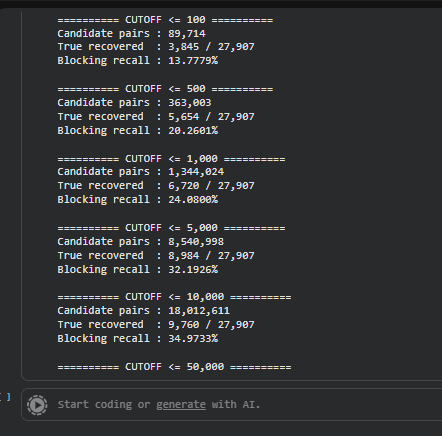

=============================
ADDRESS-TOEKN BLOCKING
=============================

In [ ]:
# ============================================
# ADDRESS-TOKEN BLOCKING
# STEP 1: CREATE ADDRESS TOKENS ON DEV DATA
# ============================================

# ---------- SOURCE 1 ----------
s1_address_tokens = (
    dev_s1_records
    .select([
        "entity_id",
        "business_address"
    ])
    .with_columns(
        pl.col("business_address")
        .fill_null("")
        .map_elements(
            normalize_basic,
            return_dtype=pl.String
        )
        .str.split(" ")
        .alias("tokens")
    )
    .explode("tokens")
    .rename({
        "entity_id": "source1_entity_id",
        "tokens": "token"
    })
    .filter(
        (pl.col("token") != "") &
        pl.col("token").is_not_null()
    )
    .select([
        "source1_entity_id",
        "token"
    ])
    .unique()
)

# ---------- SOURCE 2 ----------
s2_address_tokens = (
    dev_s2_records
    .select([
        "entity_id",
        "business_address"
    ])
    .with_columns(
        pl.col("business_address")
        .fill_null("")
        .map_elements(
            normalize_basic,
            return_dtype=pl.String
        )
        .str.split(" ")
        .alias("tokens")
    )
    .explode("tokens")
    .rename({
        "entity_id": "match_id",
        "tokens": "token"
    })
    .filter(
        (pl.col("token") != "") &
        pl.col("token").is_not_null()
    )
    .select([
        "match_id",
        "token"
    ])
    .unique()
)

print("S1 address-token rows:", s1_address_tokens.height)
print("S2 address-token rows:", s2_address_tokens.height)

In [ ]:
# Step 2: token frequency
s2_address_token_freq = (
    s2_address_tokens
    .group_by("token")
    .len()
    .sort("len", descending=True)
)

print("Unique S2 address tokens:", s2_address_token_freq.height)

print("\nMost common address tokens:")
print(s2_address_token_freq.head(30))

In [ ]:
# ============================================
# ADDRESS-TOKEN BLOCKING
# STEP 3: TRUE-PAIR TOKEN COVERAGE
# ============================================

# Attach S1 address tokens to the TRUE pairs
true_address_tokens = (
    true_pairs
    .join(
        s1_address_tokens,
        on="source1_entity_id",
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id",
        "token"
    ])
)

# Check whether the matched S2 record shares that address token
true_address_overlap = (
    true_address_tokens
    .join(
        s2_address_tokens,
        left_on=["matched_entity_id", "token"],
        right_on=["match_id", "token"],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id",
        "token"
    ])
    .unique()
)

# Count TRUE pairs having >= 1 shared address token
covered_true_pairs = (
    true_address_overlap
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
)

print("TRUE pairs:", true_pairs.height)
print(
    "TRUE pairs sharing >=1 address token:",
    covered_true_pairs.height
)

print(
    "Address-token blocking recall:",
    covered_true_pairs.height / true_pairs.height
)

In [ ]:
# How much of that 45.9% comes from useful/rare address tokens versus generic address words?

In [ ]:
# ============================================
# ADDRESS-TOKEN BLOCKING
# STEP 4: FREQUENCY CUTOFF ANALYSIS
# ============================================

# Frequency of each address token in S2
s2_address_token_freq = (
    s2_address_tokens
    .group_by("token")
    .len()
    .rename({"len": "token_freq"})
)

# Add frequency to the TRUE-pair token overlaps
true_address_overlap_freq = (
    true_address_overlap
    .join(
        s2_address_token_freq,
        on="token",
        how="left"
    )
)

print("TRUE-pair token overlaps:", true_address_overlap_freq.height)

# Test progressively stricter frequency cutoffs
cutoffs = [10, 50, 100, 500, 1000, 5000, 10000]

for cutoff in cutoffs:

    covered = (
        true_address_overlap_freq
        .filter(pl.col("token_freq") <= cutoff)
        .select([
            "source1_entity_id",
            "matched_entity_id"
        ])
        .unique()
    )

    recall = covered.height / true_pairs.height

    print(
        f"\n========== CUTOFF <= {cutoff:,} =========="
    )
    print(
        f"TRUE pairs recovered: "
        f"{covered.height:,} / {true_pairs.height:,}"
    )
    print(
        f"Address-token blocking recall: "
        f"{recall:.2%}"
    )

In [123]:
# ============================================
# ADDRESS-TOKEN BLOCKING
# STEP 5: ESTIMATE CANDIDATE VOLUME
# ============================================

s1_addr_freq = (
    s1_address_tokens
    .group_by("token")
    .len()
    .rename({"len": "s1_count"})
)

s2_addr_freq = (
    s2_address_tokens
    .group_by("token")
    .len()
    .rename({"len": "s2_count"})
)

token_stats = (
    s1_addr_freq
    .join(
        s2_addr_freq,
        on="token",
        how="inner"
    )
    .with_columns(
        (pl.col("s1_count") * pl.col("s2_count"))
        .alias("pair_hits")
    )
)

print("Shared address tokens:", token_stats.height)

for cutoff in [10, 50, 100, 500, 1000]:

    estimated_pairs = (
        token_stats
        .filter(pl.col("s2_count") <= cutoff)
        .select(
            pl.col("pair_hits").sum()
        )
        .item()
    )

    print(
        f"Cutoff <= {cutoff:>4}: "
        f"estimated pair hits = {estimated_pairs:,}"
    )

Shared address tokens: 9781
Cutoff <=   10: estimated pair hits = 52,452
Cutoff <=   50: estimated pair hits = 245,113
Cutoff <=  100: estimated pair hits = 493,298
Cutoff <=  500: estimated pair hits = 3,401,688
Cutoff <= 1000: estimated pair hits = 7,785,871


In [124]:
# ============================================
# ADDRESS-TOKEN BLOCKING
# STEP 6A: BUILD LAZY CANDIDATES
# ============================================

# Keep only address tokens whose S2 frequency is <= 500

In [125]:
allowed_address_tokens = (
    token_stats
    .filter(pl.col("s2_count") <= 500)
    .select("token")
    .lazy()
)

s2_address_block = (
    s2_address_tokens.lazy()
    .join(
        allowed_address_tokens,
        on="token",
        how="inner"
    )
    .select([
        "match_id",
        "token"
    ])
)

address_block_candidates = (
    s1_address_tokens.lazy()
    .join(
        s2_address_block,
        on="token",
        how="inner"
    )
    .select([
        "source1_entity_id",
        "match_id"
    ])
)

print("Lazy address-token candidate query created.")

Lazy address-token candidate query created.


In [126]:
# ============================================
# STEP 6B: COUNT RAW CANDIDATE HITS
# ============================================

address_hit_count = (
    address_block_candidates
    .select(
        pl.len().alias("candidate_hits")
    )
    .collect()
)

print(address_hit_count)

shape: (1, 1)
┌────────────────┐
│ candidate_hits │
│ ---            │
│ u32            │
╞════════════════╡
│ 3401688        │
└────────────────┘


In [127]:
# ============================================
# STEP 6C: UNIQUE ADDRESS-TOKEN CANDIDATE PAIRS
# ============================================

address_unique_candidates = (
    address_block_candidates
    .unique(
        subset=["source1_entity_id", "match_id"]
    )
)

address_unique_count = (
    address_unique_candidates
    .select(
        pl.len().alias("unique_candidate_pairs")
    )
    .collect()
)

print(address_unique_count)

shape: (1, 1)
┌────────────────────────┐
│ unique_candidate_pairs │
│ ---                    │
│ u32                    │
╞════════════════════════╡
│ 2927818                │
└────────────────────────┘


In [128]:
covered_true_address = (
    true_pairs.lazy()
    .join(
        address_unique_candidates,
        left_on=["source1_entity_id", "matched_entity_id"],
        right_on=["source1_entity_id", "match_id"],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .select(
        pl.len().alias("covered_true_pairs")
    )
    .collect()
)

covered_count = covered_true_address["covered_true_pairs"][0]

print("TRUE pairs:", true_pairs.height)
print("Recovered by address-token block:", covered_count)
print(
    "Address-token blocking recall:",
    covered_count / true_pairs.height
)

TRUE pairs: 27907
Recovered by address-token block: 12817
Address-token blocking recall: 0.45927545060379116


### If we UNION these blockers, how much additional TRUE-pair recall do we get, and how many unique candidates does that produce?

In [129]:
# ============================================
# STEP 7A: UNION COMPLETED BLOCKERS
# ============================================

# ---------- BASIC NAME ----------
name_candidates = (
    name_block_candidates
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s2").alias("match_id")
    ])
)

# ---------- LEGAL NAME ----------
legal_candidates = (
    legal_block_candidates
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s2").alias("match_id")
    ])
)

# ---------- ADDRESS TOKEN ----------
address_candidates = (
    address_unique_candidates
    .select([
        "source1_entity_id",
        "match_id"
    ])
)

# UNION, then remove duplicate S1-S2 pairs
union_candidates = (
    pl.concat([
        name_candidates,
        legal_candidates,
        address_candidates
    ])
    .unique(
        subset=["source1_entity_id", "match_id"]
    )
)

print("Union candidate query created.")

Union candidate query created.


In [130]:
# ============================================
# STEP 7B: COUNT UNION CANDIDATES
# ============================================

union_count = (
    union_candidates
    .select(
        pl.len().alias("candidate_pairs")
    )
    .collect()
)

print(union_count)

shape: (1, 1)
┌─────────────────┐
│ candidate_pairs │
│ ---             │
│ u32             │
╞═════════════════╡
│ 3001798         │
└─────────────────┘


In [131]:
# ============================================
# STEP 7C: UNION BLOCKING RECALL
# ============================================

covered_union = (
    true_pairs
    .lazy()
    .join(
        union_candidates,
        left_on=["source1_entity_id", "matched_entity_id"],
        right_on=["source1_entity_id", "match_id"],
        how="inner"
    )
    .select(
        pl.len().alias("covered_true_pairs")
    )
    .collect()
)

union_recovered = covered_union["covered_true_pairs"][0]

print("TRUE pairs:", true_pairs.height)
print("Recovered by UNION:", union_recovered)
print(
    "UNION blocking recall:",
    union_recovered / true_pairs.height
)

TRUE pairs: 27907
Recovered by UNION: 13081
UNION blocking recall: 0.4687354427204644


In [132]:
union_count = (
    union_candidates
    .select(
        pl.len().alias("candidate_pairs")
    )
    .collect()
)

print(union_count)

shape: (1, 1)
┌─────────────────┐
│ candidate_pairs │
│ ---             │
│ u32             │
╞═════════════════╡
│ 3001798         │
└─────────────────┘


Yep. This is a good place to create a **hard checkpoint** because we have now crossed from exploratory analysis into actual candidate-generation engineering.

I checked the project material again before writing this. The checkpoint below follows the methodology and terminology we've established in the notebook and the challenge documentation. The challenge explicitly treats blocking as a recall bottleneck and requires the final `candidate_pairs.tsv` to represent the candidate set fed to the matcher.  

### 📌 Add this as a Markdown cell right here

````markdown
# 🧠 AMAZON ML CHALLENGE 2026 — CHECKPOINT: BLOCKING / CANDIDATE GENERATION

> **Current phase:** Candidate Generation / Blocking  
> **Next phase:** Final Candidate Set → Pairwise Feature Engineering → ML Matcher

---

## 1. What are we solving?

This is a **Business Entity Resolution** problem.

For every Source 1 business, we need to identify **all matching records** from Source 2 and Source 3.

This is NOT ordinary one-to-one classification.

An S1 entity can have:

```text
0 matches
1 match
2 matches
...
many matches
````

The challenge evaluates the final predictions using **macro F0.5**, which places more emphasis on precision than recall.

Therefore:

```text
False merge  → expensive
Missed match → also bad
Correct singleton prediction → valuable
```

---

# 2. Why blocking is necessary

The training data is enormous:

```text
Source 1      ≈ 2.2M records
Source 2      ≈ 5.0M records
Source 3      ≈ 5.3M records
```

A brute-force comparison between S1 and S2 alone would require roughly:

2.2M × 5.0M ≈ 11 trillion comparisons

and S3 would add even more.

Therefore we cannot compare every S1 record against every S2/S3 record.

Instead:

```text
ALL POSSIBLE PAIRS
        ↓
     BLOCKING
        ↓
  CANDIDATE PAIRS
        ↓
 SIMILARITY FEATURES
        ↓
   ML MATCHER
        ↓
 FINAL MATCHES
```

---

# 3. The most important blocking principle

Blocking creates the **search space** for the matcher.

If a true pair is removed during blocking:

```text
TRUE PAIR
   ↓
blocked out
   ↓
classifier never sees it
   ↓
IMPOSSIBLE TO RECOVER
```

Therefore:

> **Blocking determines the upper bound of achievable recall.**

We want the candidate set to be dramatically smaller than the full Cartesian product while preserving as many true pairs as possible.

---

# 4. Our development dataset

We created a controlled development set so that we do not repeatedly operate on the entire dataset.

Current development population:

```text
S1 entities:       5,537
TRUE pairs:       27,907
FALSE pairs:      13,420
```

We use this set to investigate blocking and later train/evaluate the matcher.

Our existing baseline results were approximately:

```text
Baseline 0 macro F0.5 ≈ 0.353
Baseline 1 macro F0.5 ≈ 0.402
```

So ~0.40 is our current development benchmark.

---

# 5. What we learned about name and address

Our analysis showed that name and address provide **complementary evidence**.

Observed development-set structure:

```text
                     ADDRESS
                 weak        strong

NAME weak        ~47 TRUE    ~3,995 TRUE
                 ~13,101 FP  ~129 FP

NAME strong     ~1,452 TRUE  ~22,453 TRUE
                 ~189 FP     ~1 FP
```

Therefore:

> We should NOT require both name and address to be strong.

A genuine match may have:

```text
weak name + strong address
```

or:

```text
strong name + weak address
```

The eventual matcher should learn how these signals interact.

We should NOT hard-code today's observed distributions as rules for the hidden test.

---

# 6. Blocking signals investigated so far

We have investigated several independent blocking signals.

### A. Basic normalized-name blocking

This uses the normalized business name.

Development result:

```text
TRUE pairs:              27,907
Recovered:                2,866
Recall:                  ≈ 10.27%
```

Useful, but clearly insufficient by itself.

---

### B. Legal-name blocking

We introduced legal-suffix normalization so that variations such as legal suffixes do not prevent candidate generation.

This improved coverage relative to basic name blocking, but it is still only one signal.

The important lesson is:

> Legal-name normalization should be an additional blocking key, not the entire solution.

---

### C. Address-token blocking

We tokenized normalized addresses and investigated shared address tokens.

The completed address-token blocker recovered:

```text
TRUE pairs:              27,907
Recovered:               12,817
Recall:                  ≈ 45.93%
```

This is currently our strongest individual blocker.

---

### D. Name-token blocking

We are currently investigating this blocker.

We measured token frequencies and discovered that:

```text
Very common tokens
        ↓
produce enormous candidate sets

Rare/informative tokens
        ↓
provide much more selective blocking
```

Earlier experiments showed that name-token blocking can recover substantial numbers of true pairs.

However, very large token-frequency cutoffs caused significant computational cost.

Therefore we will evaluate this blocker incrementally rather than blindly using the largest cutoff.

---

# 7. Why we combine blockers using UNION

We do NOT want:

```text
Name block
    AND
Address block
    AND
Legal-name block
```

because this would discard genuine matches that only satisfy one signal.

Instead:

```text
Basic-name candidates
        +
Legal-name candidates
        +
Address-token candidates
        +
Name-token candidates
        +
Future independent blockers
        ↓
      UNION
        ↓
FINAL CANDIDATE SET
```

The philosophy is:

> **Different blockers provide different opportunities to recover true pairs.**

---

# 8. Current UNION checkpoint

Our current UNION contains:

```text
Candidate pairs:       3,001,798
TRUE pairs:               27,907
Recovered TRUE pairs:     13,081

Blocking recall:
13,081 / 27,907 ≈ 46.87%
```

Therefore the current blocker combination still misses:

```text
27,907 - 13,081 = 14,826
```

known true pairs.

Approximately:

```text
53.13% of true pairs
```

are still outside the current candidate set.

Therefore:

> **We are NOT ready to freeze the candidate set yet.**

---

# 9. What the current result tells us

Address-token blocking currently contributes most of the recall.

However, the UNION is only slightly better than address-token blocking alone:

```text
Address-token recall:    ≈ 45.93%
Current UNION recall:    ≈ 46.87%
```

So the existing blockers overlap heavily.

This is actually useful information.

It tells us that the next blocker should ideally provide **independent coverage**, rather than simply generating more candidates similar to those already recovered.

This is why name-token blocking is the next important experiment.

---

# 10. What we are doing NEXT

### Step 1

Finish measuring:

```text
NAME-TOKEN BLOCKING
```

at computationally reasonable frequency cutoffs.

We care about:

```text
candidate volume
        +
new TRUE pairs recovered
        +
blocking recall
```

---

### Step 2

Add name-token candidates to the existing UNION:

```text
CURRENT UNION
     +
NAME-TOKEN CANDIDATES
     ↓
NEW UNION
```

Then measure:

```text
total candidate pairs
total TRUE pairs recovered
blocking recall
```

The important metric is **marginal recall gain**.

We want to know:

> How many of the 14,826 currently missed true pairs does name-token blocking recover?

---

### Step 3

If necessary, investigate additional independent blockers:

```text
Rare-name-token blocking
Address-token variants
Country + name/address signals
Other selective blocking keys
```

But we should NOT keep adding blockers indefinitely.

Every blocker has a cost:

```text
more recall
     ↕
more candidate pairs
     ↕
more computation
```

We are looking for the best practical trade-off.

---

# 11. The eventual target architecture

Our final pipeline should look approximately like:

```text
                SOURCE 1
                    │
                    │
          ┌─────────┴─────────┐
          │                   │
       Source 2            Source 3
          │                   │
          └─────────┬─────────┘
                    ↓
             BLOCKING LAYER
                    │
       ┌────────────┼────────────┐
       │            │            │
    Name        Address       Legal-name
    token        token          block
       │            │            │
       └────────────┼────────────┘
                    ↓
                  UNION
                    ↓
          FINAL CANDIDATE SET
                    ↓
          PAIRWISE FEATURES
                    │
       ┌────────────┼─────────────┐
       │            │             │
      Name       Address        Country
    similarity   similarity      match
       │            │             │
       └────────────┼─────────────┘
                    ↓
               ML MATCHER
                    ↓
             match probability
                    ↓
             F0.5 threshold
                    ↓
             FINAL MATCHES
```

---

# 12. What comes after blocking?

Once blocking is sufficiently strong:

### Feature engineering

For every candidate pair we will calculate features such as:

```text
NAME
├── normalized exact match
├── legal-normalized exact match
├── token Jaccard
├── character similarity
└── potentially TF-IDF similarity

ADDRESS
├── normalized exact match
├── token Jaccard
├── character similarity
└── component/token overlap

OTHER
├── country agreement
├── missing-value indicators
└── potentially blocker-derived features
```

Then:

```text
candidate pair
      ↓
feature vector
      ↓
binary classifier
      ↓
P(match)
      ↓
threshold tuned for macro F0.5
```

---

# 13. Important distinction to remember

There are TWO different problems:

### Blocking

> "Could these two records possibly represent the same entity?"

Goal:

**High recall**

---

### Matching

> "Given that these two records are candidates, are they actually the same entity?"

Goal:

**High precision + good recall**

Because the challenge uses F0.5, precision is especially important.

Therefore:

```text
BLOCKING
→ err toward recall

MATCHER
→ carefully control false positives
```

---

# 🎯 CHECKPOINT

Current status:

```text
✅ Dataset understood
✅ Ground truth structure understood
✅ Development set established
✅ F0.5 evaluation established
✅ Name similarity investigated
✅ Address similarity investigated
✅ Basic-name blocker tested
✅ Legal-name blocker tested
✅ Address-token blocker tested
✅ UNION architecture established

🔄 Name-token blocker being evaluated

⏳ Final blocking strategy
⏳ Final candidate set
⏳ Pairwise feature engineering
⏳ ML matcher
⏳ F0.5 threshold optimization
⏳ Error analysis
⏳ Test-set inference
⏳ Submission generation
```

## One-line memory hook

> **We have moved from "understanding the data" to "engineering the search space": multiple blocking signals are being UNIONed to recover as many true pairs as possible before the ML matcher ever sees a candidate.**


In [133]:
# ============================================#
# STEP 8A: NAME-TOKEN BLOCKING EXPERIMENT
# Evaluate candidate volume + TRUE-pair recovery
# WITHOUT building one giant final UNION yet.
# ============================================#

# We already have:
# s1_name_tokens: source1_entity_id, token (LazyFrame)
# s2_name_tokens: entity_id, token (LazyFrame)
# s2_token_freq: token frequency table (DataFrame)
# true_pairs: source1_entity_id, matched_entity_id (DataFrame)

cutoffs = [100, 500, 1_000, 5_000, 10_000]

for cutoff in cutoffs:

    print(f"\n========== NAME TOKEN CUTOFF <= {cutoff:,} ==========")

    # Convert allowed_tokens to a LazyFrame to join with s2_name_tokens (which is a LazyFrame)
    allowed_tokens = (
        s2_token_freq
        .filter(pl.col("len") <= cutoff)
        .select("token")
        .lazy()
    )

    # Keep only S2 token rows using allowed tokens
    s2_allowed = (
        s2_name_tokens
        .join(
            allowed_tokens,
            on="token",
            how="inner"
        )
        .select([
            "entity_id",
            "token"
        ])
    )

    # Candidate pairs sharing at least one allowed token
    name_token_candidates = (
        s1_name_tokens
        .join(
            s2_allowed,
            on="token",
            how="inner"
        )
        .select([
            "source1_entity_id",
            pl.col("entity_id").alias("match_id")
        ])
        .unique()
    )

    # Candidate volume
    candidate_count = (
        name_token_candidates
        .select(
            pl.len().alias("candidate_pairs")
        )
        .collect()["candidate_pairs"][0]
    )

    # TRUE-pair recovery
    recovered_true = (true_pairs
        .lazy()
        .join(
            name_token_candidates,
            left_on=[
                "source1_entity_id",
                "matched_entity_id"
            ],
            right_on=[
                "source1_entity_id",
                "match_id"
            ],
            how="inner"
        )
        .select(
            pl.len().alias("recovered")
        )
        .collect()["recovered"][0]
    )

    recall = recovered_true / true_pairs.height

    print(f"Candidate pairs:      {candidate_count:,}")
    print(
        f"TRUE recovered:       "
        f"{recovered_true:,} / {true_pairs.height:,}"
    )
    print(f"Name-token recall:     {recall:.2%}")


========== NAME TOKEN CUTOFF <= 100 ==========
Candidate pairs:      89,714
TRUE recovered:       3,845 / 27,907
Name-token recall:     13.78%

========== NAME TOKEN CUTOFF <= 500 ==========
Candidate pairs:      363,003
TRUE recovered:       5,654 / 27,907
Name-token recall:     20.26%

========== NAME TOKEN CUTOFF <= 1,000 ==========
Candidate pairs:      1,344,024
TRUE recovered:       6,720 / 27,907
Name-token recall:     24.08%

========== NAME TOKEN CUTOFF <= 5,000 ==========
Candidate pairs:      8,540,998
TRUE recovered:       8,984 / 27,907
Name-token recall:     32.19%

========== NAME TOKEN CUTOFF <= 10,000 ==========
Candidate pairs:      18,012,611
TRUE recovered:       9,760 / 27,907
Name-token recall:     34.97%


In [134]:
# ============================================
# STEP 8B: INCREMENTAL NAME-TOKEN RECALL
# How many TRUE pairs does name-token blocking
# recover that our existing UNION misses?
# ============================================

cutoff = 10_000

# --------------------------------------------
# 1. Keep S2 tokens whose frequency <= cutoff
# --------------------------------------------

allowed_tokens = (
    s2_token_freq
    .filter(pl.col("len") <= cutoff)
    .select("token")
    .lazy()
)

# --------------------------------------------
# 2. Keep only S2 records containing
#    those allowed tokens
# --------------------------------------------

s2_allowed = (
    s2_name_tokens
    .join(
        allowed_tokens,
        on="token",
        how="inner"
    )
    .select([
        "entity_id",
        "token"
    ])
)

# --------------------------------------------
# 3. Generate name-token candidate pairs
# --------------------------------------------

name_token_candidates = (
    s1_name_tokens
    .join(
        s2_allowed,
        on="token",
        how="inner"
    )
    .select([
        "source1_entity_id",
        pl.col("entity_id").alias("match_id")
    ])
    .unique()
)

# --------------------------------------------
# 4. TRUE pairs recovered by name-token block
# --------------------------------------------

name_token_true = (
    true_pairs
    .lazy()
    .join(
        name_token_candidates,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

# --------------------------------------------
# 5. TRUE pairs already recovered by UNION
# --------------------------------------------

union_true = (
    true_pairs
    .lazy()
    .join(
        union_candidates,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

# --------------------------------------------
# 6. Find NEW TRUE pairs contributed by
#    name-token blocking
# --------------------------------------------

new_true_from_name_token = (
    name_token_true
    .join(
        union_true,
        on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        how="anti"
    )
)

# --------------------------------------------
# 7. Results
# --------------------------------------------

name_token_recovered = name_token_true.height
union_recovered = union_true.height
new_count = new_true_from_name_token.height

print("===========================================")
print("NAME-TOKEN INCREMENTAL RECALL")
print("===========================================")

print(
    "Name-token TRUE recovered:",
    name_token_recovered
)

print(
    "Already recovered by UNION:",
    name_token_recovered - new_count
)

print(
    "NEW TRUE pairs from name-token:",
    new_count
)

print(
    "Incremental recall:",
    f"{new_count / true_pairs.height:.2%}"
)

print(
    "Potential combined recall:",
    f"{(union_recovered + new_count) / true_pairs.height:.2%}"
)

NAME-TOKEN INCREMENTAL RECALL
Name-token TRUE recovered: 9760
Already recovered by UNION: 9482
NEW TRUE pairs from name-token: 278
Incremental recall: 1.00%
Potential combined recall: 47.87%


Our current evidence says:
```
Blocker	                        Contribution
Existing UNION	                 46.87% total recall
Name-token ≤10k	                 34.97% standalone
Name-token NEW contribution	     +1.00%
Combined	                       47.87%
```

In [135]:
# ============================================
# STEP 9: RARE NAME-TOKEN BLOCKING
# First test: tokens appearing <= 500 times in S2
# ============================================

rare_cutoff = 500

# --------------------------------------------
# 1. Select rare/informative S2 name tokens
# --------------------------------------------

rare_tokens = (
    s2_token_freq
    .lazy()
    .filter(
        pl.col("len") <= rare_cutoff
    )
    .select("token")
)

# --------------------------------------------
# 2. Keep only S2 records containing
#    those rare tokens
# --------------------------------------------

s2_rare_tokens = (
    s2_name_tokens
    .join(
        rare_tokens,
        on="token",
        how="inner"
    )
    .select([
        "entity_id",
        "token"
    ])
)

# --------------------------------------------
# 3. Generate rare-token candidate pairs
# --------------------------------------------

rare_name_candidates = (
    s1_name_tokens
    .join(
        s2_rare_tokens,
        on="token",
        how="inner"
    )
    .select([
        "source1_entity_id",
        pl.col("entity_id").alias("match_id")
    ])
    .unique(
        subset=[
            "source1_entity_id",
            "match_id"
        ]
    )
)

print("Rare-name candidate query created.")

Rare-name candidate query created.


In [136]:
# counting candidates
rare_candidate_count = (
    rare_name_candidates
    .select(
        pl.len().alias("candidate_pairs")
    )
    .collect()
)

print(rare_candidate_count)

shape: (1, 1)
┌─────────────────┐
│ candidate_pairs │
│ ---             │
│ u32             │
╞═════════════════╡
│ 363003          │
└─────────────────┘


In [137]:
# ============================================
# STEP 9B: RARE NAME-TOKEN TRUE-PAIR RECALL
# ============================================

rare_true = (
    true_pairs
    .lazy()
    .join(
        rare_name_candidates,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

print(
    "Rare-name TRUE pairs recovered:",
    rare_true.height
)

print(
    "Rare-name blocking recall:",
    f"{rare_true.height / true_pairs.height:.2%}"
)

Rare-name TRUE pairs recovered: 5654
Rare-name blocking recall: 20.26%


In [138]:
# ============================================
# STEP 9C: INCREMENTAL RARE-TOKEN CONTRIBUTION
# ============================================

union_true = (
    true_pairs
    .lazy()
    .join(
        union_candidates,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

new_true_from_rare = (
    rare_true
    .join(
        union_true,
        on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        how="anti"
    )
)

new_rare_count = new_true_from_rare.height

print("============================================")
print("RARE NAME-TOKEN INCREMENTAL RECALL")
print("============================================")

print(
    "Rare-name TRUE recovered:",
    rare_true.height
)

print(
    "Already recovered by UNION:",
    rare_true.height - new_rare_count
)

print(
    "NEW TRUE pairs from rare-token:",
    new_rare_count
)

print(
    "Incremental recall:",
    f"{new_rare_count / true_pairs.height:.2%}"
)

print(
    "Potential combined recall:",
    f"{(union_true.height + new_rare_count) / true_pairs.height:.2%}"
)

RARE NAME-TOKEN INCREMENTAL RECALL
Rare-name TRUE recovered: 5654
Already recovered by UNION: 5493
NEW TRUE pairs from rare-token: 161
Incremental recall: 0.58%
Potential combined recall: 47.45%


| Metric                 |             Result |
| ---------------------- | -----------------: |
| Candidate pairs        |        **363,003** |
| TRUE pairs recovered   | **5,654 / 27,907** |
| Standalone recall      |         **20.26%** |
| Already in UNION       |          **5,493** |
| **NEW TRUE pairs**     |            **161** |
| **Incremental recall** |          **0.58%** |
| Combined recall        |         **47.45%** |


In [139]:
# ============================================
# STEP 9D: RARE TOKEN CUTOFF COMPARISON
# Test a stricter cutoff of 100
# ============================================

rare_cutoff_100 = 100

allowed_tokens_100 = (
    s2_token_freq
    .lazy()
    .filter(
        pl.col("len") <= rare_cutoff_100
    )
    .select("token")
)

s2_rare_tokens_100 = (
    s2_name_tokens
    .join(
        allowed_tokens_100,
        on="token",
        how="inner"
    )
    .select([
        "entity_id",
        "token"
    ])
)

rare_candidates_100 = (
    s1_name_tokens
    .join(
        s2_rare_tokens_100,
        on="token",
        how="inner"
    )
    .select([
        "source1_entity_id",
        pl.col("entity_id").alias("match_id")
    ])
    .unique()
)

rare_true_100 = (
    true_pairs
    .lazy()
    .join(
        rare_candidates_100,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

new_true_100 = (
    rare_true_100
    .join(
        union_true,
        on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        how="anti"
    )
)

candidate_count_100 = (
    rare_candidates_100
    .select(pl.len().alias("candidate_pairs"))
    .collect()
)["candidate_pairs"][0]

new_count_100 = new_true_100.height

print("============================================")
print("RARE TOKEN CUTOFF <= 100")
print("============================================")

print("Candidate pairs:", candidate_count_100)
print("TRUE recovered:", rare_true_100.height)
print(
    "Standalone recall:",
    f"{rare_true_100.height / true_pairs.height:.2%}"
)
print("NEW TRUE from rare-token:", new_count_100)
print(
    "Incremental recall:",
    f"{new_count_100 / true_pairs.height:.2%}"
)
print(
    "Combined recall:",
    f"{(union_true.height + new_count_100) / true_pairs.height:.2%}"
)

RARE TOKEN CUTOFF <= 100
Candidate pairs: 89714
TRUE recovered: 3845
Standalone recall: 13.78%
NEW TRUE from rare-token: 119
Incremental recall: 0.43%
Combined recall: 47.30%


### Rare-name-token blocking with frequency ≤100 provides a strong low-cost incremental blocker. We will retain it provisionally and evaluate it as part of the final UNION.

```          
                ┌── Name block
                │
                ├── Legal-name block
                │
                ├── Name-token block
S1 ─────────────┼── Address-token block
                │
                └── Rare-name-token ≤100
                         │
                         ▼
                      UNION
                         │
                         ▼
                FINAL CANDIDATES
                         │
                         ▼
                 ML MATCHER
  ```
  

```
UNION currently:
3,001,798 candidate pairs
13,081 / 27,907 TRUE pairs
46.87% recall

```



In [140]:
# ============================================
# STEP 10A: ADD RARE-NAME-TOKEN <=100 TO UNION
# ============================================

final_candidates_test = (
    pl.concat(
        [
            union_candidates.select([
                "source1_entity_id",
                "match_id"
            ]),
            rare_candidates_100.select([
                "source1_entity_id",
                "match_id"
            ])
        ],
        how="vertical"
    )
    .unique()
)

final_candidate_count = (
    final_candidates_test
    .select(
        pl.len().alias("candidate_pairs")
    )
    .collect()["candidate_pairs"][0]
)

print("============================================")
print("UNION + RARE-NAME-TOKEN <=100")
print("============================================")
print("Candidate pairs:", final_candidate_count)

UNION + RARE-NAME-TOKEN <=100
Candidate pairs: 3086442


In [141]:
# ============================================
# STEP 10B: RECALL OF EXPANDED UNION
# ============================================

covered_expanded = (
    true_pairs
    .lazy()
    .join(
        final_candidates_test,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

expanded_recovered = covered_expanded.height

print("============================================")
print("EXPANDED UNION RECALL")
print("============================================")
print("TRUE pairs:", true_pairs.height)
print("Recovered by expanded UNION:", expanded_recovered)
print(
    "Blocking recall:",
    f"{expanded_recovered / true_pairs.height:.2%}"
)

EXPANDED UNION RECALL
TRUE pairs: 27907
Recovered by expanded UNION: 13200
Blocking recall: 47.30%


### We have completed the first serious S2 blocking investigation and discovered that our apparent ~47% recall ceiling is largely because the current blocker UNION only covers S2 while our denominator contains both S2 and S3 true pairs. We should now mirror the blocking strategy for S3, combine S2 + S3 candidates, measure the true global blocking recall, and only then move into pairwise feature engineering and the ML matcher.

In [142]:
# ============================================
# S3 BLOCKING
# STEP 1: CREATE S3 BLOCKING TABLE
# ============================================

s3_block = (
    s3
    .select([
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ])
    .with_columns([
        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_basic,
            return_dtype=pl.String
        )
        .alias("name_basic"),

        pl.col("business_name")
        .fill_null("")
        .map_elements(
            normalize_legal_suffix,
            return_dtype=pl.String
        )
        .alias("name_legal")
    ])
)

print("S3 schema:")
print(s3_block.collect_schema().names())

S3 schema:
['entity_id', 'business_name', 'business_address', 'country', 'name_basic', 'name_legal']


In [143]:
# ============================================
# S3 BLOCKING
# STEP 2: NAME + LEGAL NAME
# ============================================

# TRUE S3 pairs
true_s3_pairs = (
    true_pairs
    .filter(
        pl.col("matched_entity_id")
        .str.starts_with("S3-")
    )
)

print("Total S3 TRUE pairs:", true_s3_pairs.height)


# ---------- BASIC NAME ----------

s3_name_candidates = (
    dev_s1_block
    .lazy()
    .select([
        "entity_id",
        "name_basic"
    ])
    .join(
        s3_block.select([
            "entity_id",
            "name_basic"
        ]),
        on="name_basic",
        how="inner",
        suffix="_s3"
    )
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s3").alias("match_id")
    ])
    .unique()
)

s3_name_count = (
    s3_name_candidates
    .select(
        pl.len().alias("candidate_pairs")
    )
    .collect()["candidate_pairs"][0]
)


# ---------- LEGAL NAME ----------

s3_legal_candidates = (
    dev_s1_block
    .lazy()
    .select([
        "entity_id",
        "name_legal"
    ])
    .join(
        s3_block.select([
            "entity_id",
            "name_legal"
        ]),
        on="name_legal",
        how="inner",
        suffix="_s3"
    )
    .select([
        pl.col("entity_id").alias("source1_entity_id"),
        pl.col("entity_id_s3").alias("match_id")
    ])
    .unique()
)

s3_legal_count = (
    s3_legal_candidates
    .select(
        pl.len().alias("candidate_pairs")
    )
    .collect()["candidate_pairs"][0]
)


print("\n============================================")
print("S3 NAME BLOCK")
print("============================================")
print("Candidate pairs:", s3_name_count)


print("\n============================================")
print("S3 LEGAL-NAME BLOCK")
print("============================================")
print("Candidate pairs:", s3_legal_count)

Total S3 TRUE pairs: 14487

S3 NAME BLOCK
Candidate pairs: 30376

S3 LEGAL-NAME BLOCK
Candidate pairs: 85739


In [144]:
# ============================================
# S3 BLOCKING
# STEP 3: NAME + LEGAL RECALL
# ============================================

s3_name_true = (
    true_s3_pairs
    .lazy()
    .join(
        s3_name_candidates,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

s3_legal_true = (
    true_s3_pairs
    .lazy()
    .join(
        s3_legal_candidates,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)


print("============================================")
print("S3 BLOCKING RECALL")
print("============================================")

print(
    "Name TRUE recovered:",
    s3_name_true.height,
    "/",
    true_s3_pairs.height
)

print(
    "Name recall:",
    f"{s3_name_true.height / true_s3_pairs.height:.2%}"
)

print()

print(
    "Legal-name TRUE recovered:",
    s3_legal_true.height,
    "/",
    true_s3_pairs.height
)

print(
    "Legal-name recall:",
    f"{s3_legal_true.height / true_s3_pairs.height:.2%}"
)

S3 BLOCKING RECALL
Name TRUE recovered: 3190 / 14487
Name recall: 22.02%

Legal-name TRUE recovered: 4942 / 14487
Legal-name recall: 34.11%


What's currently happening:
```
S2
 ├── basic name
 ├── legal name
 ├── address token
 ├── name token
 └── rare name token
             ↓
         S2 UNION
             ↓
        47.30% global
        recall so far


S3
 ├── basic name       ← NOW
 ├── legal name       ← NOW
 ├── address token    ← NEXT
 ├── name token       ← NEXT
 └── rare name token  ← NEXT
             ↓
         S3 UNION
             ↓
              ?
```

Then finally ->
```
                 S2 UNION
                    +
                 S3 UNION
                    ↓
              GLOBAL UNION
                    ↓
           FINAL BLOCKING RECALL
                    ↓
             PAIRWISE FEATURES
                    ↓
               ML MATCHER
```

In [145]:
# ============================================
# S3 ADDRESS-TOKEN BLOCKING
# STEP 1: CREATE S3 ADDRESS TOKEN TABLE
# ============================================

s3_address_tokens = (
    s3_block
    .select([
        "entity_id",
        "business_address"
    ])
    .with_columns(
        pl.col("business_address")
        .fill_null("")
        .map_elements(
            normalize_basic,
            return_dtype=pl.String
        )
        .str.split(by=" ")
        .alias("tokens")
    )
    .explode("tokens")
    .rename({
        "entity_id": "match_id",
        "tokens": "token"
    })
    .filter(
        (pl.col("token") != "") &
        (pl.col("token").is_not_null())
    )
    .select([
        "match_id",
        "token"
    ])
    .unique()
    .collect() # materializes the LazyFrame into a DataFrame so we can access .height
)

print("S3 address-token rows:", s3_address_tokens.height)
print("S3 address-token schema:", s3_address_tokens.columns)

S3 address-token rows: 40377661
S3 address-token schema: ['match_id', 'token']


In [146]:
# ============================================
# S3 ADDRESS-TOKEN BLOCKING
# STEP 2: TOKEN FREQUENCY
# ============================================

s3_address_token_freq = (
    s3_address_tokens
    .group_by("token")
    .len()
    .sort("len", descending=True)
)

print("Unique S3 address tokens:", s3_address_token_freq.height)

print("\nMost common S3 address tokens:")
print(s3_address_token_freq.head(30))

Unique S3 address tokens: 580069

Most common S3 address tokens:
shape: (30, 2)
┌────────┬────────┐
│ token  ┆ len    │
│ ---    ┆ ---    │
│ str    ┆ u32    │
╞════════╪════════╡
│ no     ┆ 911355 │
│ road   ┆ 619124 │
│ new    ┆ 466739 │
│ street ┆ 357143 │
│ city   ┆ 352105 │
│ …      ┆ …      │
│ unit   ┆ 196849 │
│ west   ┆ 191943 │
│ ohio   ┆ 188077 │
│ b      ┆ 187648 │
│ h      ┆ 183870 │
└────────┴────────┘


In [147]:
# ============================================
# S3 ADDRESS-TOKEN BLOCKING
# STEP 3: TEST TOKEN FREQUENCY CUTOFFS
# ============================================

cutoffs = [10, 50, 100, 500, 1_000, 5_000, 10_000]

for cutoff in cutoffs:

    print(f"\n========== CUTOFF <= {cutoff:,} ==========")

    # Tokens occurring at most `cutoff` times in S3
    allowed_tokens = (
        s3_address_token_freq
        .filter(pl.col("len") <= cutoff)
        .select("token")
    )

    # Keep only S3 address tokens that pass the frequency cutoff
    s3_allowed = (
        s3_address_tokens
        .join(
            allowed_tokens,
            on="token",
            how="inner"
        )
        .select([
            "match_id",
            "token"
        ])
    )

    # Candidate pairs generated by this cutoff
    address_candidates = (
        s1_address_tokens
        .join(
            s3_allowed,
            on="token",
            how="inner"
        )
        .select([
            "source1_entity_id",
            "match_id"
        ])
        .unique()
    )

    candidate_count = address_candidates.height

    # TRUE S3 pairs recovered
    covered_true = (
        true_s3_pairs
        .lazy()
        .join(
            address_candidates.lazy(),
            left_on=[
                "source1_entity_id",
                "matched_entity_id"
            ],
            right_on=[
                "source1_entity_id",
                "match_id"
            ],
            how="inner"
        )
        .select([
            "source1_entity_id",
            "matched_entity_id"
        ])
        .unique()
        .collect()
    )

    recovered = covered_true.height

    print("Candidate pairs:", f"{candidate_count:,}")
    print(
        "TRUE recovered:",
        f"{recovered:,} / {true_s3_pairs.height:,}"
    )
    print(
        "Address-token recall:",
        f"{recovered / true_s3_pairs.height:.2%}"
    )


========== CUTOFF <= 10 ==========
Candidate pairs: 5,485
TRUE recovered: 2,145 / 14,487
Address-token recall: 14.81%

========== CUTOFF <= 50 ==========
Candidate pairs: 45,495
TRUE recovered: 4,417 / 14,487
Address-token recall: 30.49%

========== CUTOFF <= 100 ==========
Candidate pairs: 125,920
TRUE recovered: 5,733 / 14,487
Address-token recall: 39.57%

========== CUTOFF <= 500 ==========
Candidate pairs: 1,161,037
TRUE recovered: 9,578 / 14,487
Address-token recall: 66.11%

========== CUTOFF <= 1,000 ==========
Candidate pairs: 2,817,979
TRUE recovered: 10,964 / 14,487
Address-token recall: 75.68%

========== CUTOFF <= 5,000 ==========
Candidate pairs: 22,978,411
TRUE recovered: 12,974 / 14,487
Address-token recall: 89.56%

========== CUTOFF <= 10,000 ==========
Candidate pairs: 58,235,122
TRUE recovered: 13,289 / 14,487
Address-token recall: 91.73%


#### Current roadmap ->
```
S2
 ├─ name
 ├─ legal-name
 ├─ address-token
 └─ rare/name-token
        ↓
   S2 UNION

S3
 ├─ name
 ├─ legal-name
 ├─ address-token
 └─ name/rare-token
        ↓
   S3 UNION

S2 UNION + S3 UNION
        ↓
 GLOBAL UNION
        ↓
 FINAL CANDIDATES
        ↓
 PAIRWISE FEATURES
        ↓
 ML MATCHER
        ↓
 F0.5 THRESHOLD
        ↓
 FINAL MATCHES
```

At ≤1,000 we get:
```
2,817,979 candidates
10,964 / 14,487 TRUE S3 pairs
75.68% S3 recall
```
Materializing that S3 address blocker now. 
#### Step: Build S3 address-token candidates at cutoff 1,000

In [148]:
# ============================================
# S3 ADDRESS-TOKEN BLOCKING
# FINAL SELECTED CUTOFF = 1,000
# ============================================

cutoff = 1_000

# Keep only relatively selective S3 address tokens
allowed_s3_address_tokens = (
    s3_address_token_freq
    .filter(pl.col("len") <= cutoff)
    .select("token")
)

# Keep S3 records containing those tokens
s3_address_allowed = (
    s3_address_tokens
    .join(
        allowed_s3_address_tokens,
        on="token",
        how="inner"
    )
    .select([
        "match_id",
        "token"
    ])
)

# Generate S1 -> S3 candidate pairs
s3_address_candidates_1000 = (
    s1_address_tokens
    .join(
        s3_address_allowed,
        on="token",
        how="inner"
    )
    .select([
        "source1_entity_id",
        "match_id"
    ])
    .unique()
)

print(
    "S3 address-token candidates:",
    s3_address_candidates_1000.height
)

S3 address-token candidates: 2817979


In [149]:
# ============================================
# VERIFY S3 ADDRESS-TOKEN RECALL
# ============================================

s3_address_true_1000 = (
    true_s3_pairs
    .lazy()
    .join(
        s3_address_candidates_1000.lazy(),
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

s3_address_recovered_1000 = s3_address_true_1000.height

print("============================================")
print("S3 ADDRESS-TOKEN BLOCKING")
print("============================================")
print("TRUE S3 pairs:", true_s3_pairs.height)
print(
    "Recovered:",
    s3_address_recovered_1000,
    "/",
    true_s3_pairs.height
)
print(
    "Blocking recall:",
    f"{s3_address_recovered_1000 / true_s3_pairs.height:.2%}"
)

S3 ADDRESS-TOKEN BLOCKING
TRUE S3 pairs: 14487
Recovered: 10964 / 14487
Blocking recall: 75.68%


In [151]:
# ============================================
# CHECK EXISTING S3 CANDIDATE OBJECTS
# No recomputation
# ============================================

candidate_names = [
    name for name in list(globals().keys())
    if name.startswith("s3_") and "candidate" in name.lower()
]

for name in candidate_names:
    obj = globals()[name]

    print(f"\n{name}")
    print("type:", type(obj).__name__)

    if isinstance(obj, pl.DataFrame):
        print("columns:", obj.columns)

    elif isinstance(obj, pl.LazyFrame):
        print("schema:", obj.collect_schema().names())


s3_baseline_candidates
type: DataFrame
columns: ['entity_id', 'business_name', 'business_address', 'country', 'match_key']

s3_legal_candidates
type: LazyFrame
schema: ['source1_entity_id', 'match_id']

s3_name_candidates
type: LazyFrame
schema: ['source1_entity_id', 'match_id']

s3_address_candidates_1000
type: DataFrame
columns: ['source1_entity_id', 'match_id']


=============================
S3 UNION BLOCKING
=============================

In [152]:
# ============================================
# STEP: S3 UNION BLOCKING
# NAME + LEGAL-NAME + ADDRESS-TOKEN
# ============================================

s3_union_candidates = (
    pl.concat([
        s3_name_candidates,
        s3_legal_candidates,
        s3_address_candidates_1000.lazy()
    ])
    .unique()
)

print("S3 UNION candidate set created.")

s3_union_count = (
    s3_union_candidates
    .select(pl.len().alias("candidate_pairs"))
    .collect()
)

print(s3_union_count)

S3 UNION candidate set created.
shape: (1, 1)
┌─────────────────┐
│ candidate_pairs │
│ ---             │
│ u32             │
╞═════════════════╡
│ 2899739         │
└─────────────────┘


In [154]:
# ============================================
# S3 UNION BLOCKING RECALL
# ============================================

s3_union_true = (
    true_s3_pairs
    .lazy()
    .join(
        s3_union_candidates,
        left_on=["source1_entity_id", "matched_entity_id"],
        right_on=["source1_entity_id", "match_id"],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

s3_union_recovered = s3_union_true.height

print("========================================")
print("S3 UNION BLOCKING RECALL")
print("========================================")
print("TRUE S3 pairs:", true_s3_pairs.height)
print("Recovered by S3 UNION:", s3_union_recovered)
print(
    "S3 UNION blocking recall:",
    f"{s3_union_recovered / true_s3_pairs.height:.2%}"
)

S3 UNION BLOCKING RECALL
TRUE S3 pairs: 14487
Recovered by S3 UNION: 12186
S3 UNION blocking recall: 84.12%


```
S3 TRUE pairs:             14,487
S3 UNION candidates:    2,899,739
S3 UNION recovered:       12,186
S3 UNION recall:            84.12%
```

#### Q: What happens to the full S3 UNION at 5k and 10k?

In [155]:
# Check which S3 address candidate sets already exist

for name in [
    "s3_address_candidates_1000",
    "s3_address_candidates_5000",
    "s3_address_candidates_10000"
]:
    if name in globals():
        obj = globals()[name]
        print(name, "->", type(obj).__name__)
        print("   rows:", obj.height if isinstance(obj, pl.DataFrame) else "LazyFrame")
    else:
        print(name, "-> NOT IN MEMORY")

s3_address_candidates_1000 -> DataFrame
   rows: 2817979
s3_address_candidates_5000 -> NOT IN MEMORY
s3_address_candidates_10000 -> NOT IN MEMORY


### Combine S2 + S2

In [156]:
# ============================================
# STEP 11A: FINAL S2 + S3 CANDIDATE UNION
# ============================================

final_candidates = (
    pl.concat([
        union_candidates,
        s3_union_candidates
    ])
    .unique()
)

print("Final candidate set created.")

SyntaxError: unmatched ')' (4059491298.py, line 1)

In [ ]:
final_candidate_count = (
    final_candidates
    .select(
        pl.len().alias("candidate_pairs")
    )
    .collect()
)

print(final_candidate_count)

In [ ]:
# ============================================
# STEP 10B: OVERALL BLOCKING RECALL
# ============================================

final_true = (
    true_pairs
    .lazy()
    .join(
        final_candidates,
        left_on=[
            "source1_entity_id",
            "matched_entity_id"
        ],
        right_on=[
            "source1_entity_id",
            "match_id"
        ],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "matched_entity_id"
    ])
    .unique()
    .collect()
)

final_recovered = final_true.height

print("========================================")
print("FINAL BLOCKING RECALL")
print("========================================")
print("TRUE pairs:", true_pairs.height)
print("Recovered:", final_recovered)
print(
    "Blocking recall:",
    f"{final_recovered / true_pairs.height:.2%}"
)

### Current worflow position:
```
              ~11T+ possible comparisons
                       │
                       ▼
                  BLOCKING
                       │
                       ▼
              5.90M candidates
                       │
                 90.54% recall
                       │
                       ▼
             ┌─────────────────┐
             │  ML MATCHER     │
             │                 │
             │ name similarity │
             │ address sim.    │
             │ country         │
             │ token overlap   │
             │ etc.            │
             └─────────────────┘
                       │
                       ▼
                 P(match)
                       │
                       ▼
                 F0.5 threshold
                       │
                       ▼
                 FINAL MATCHES
```

```
FINAL CANDIDATE PAIRS:   5,901,537

TRUE PAIRS:                 27,907
TRUE PAIRS RECOVERED:       25,267

FINAL BLOCKING RECALL:       90.54%
```

In [ ]:
# ============================================
# STEP 11A: INSPECT FINAL CANDIDATE SET
# ============================================

print("FINAL CANDIDATE SCHEMA:")
print(final_candidates.collect_schema())

print("\nSAMPLE:")
print(final_candidates.head(10).collect())

print("\nCANDIDATE COUNT:")
print(
    final_candidates
    .select(pl.len().alias("candidate_pairs"))
    .collect()
)

#### Next stages:
```
FINAL CANDIDATES
      │
      ├── identify TRUE / FALSE pairs
      │
      ↓
TRAINING DATA
      │
      ├── positive examples
      └── sampled negative examples
      │
      ↓
FEATURE ENGINEERING
      │
      ├── name similarity
      ├── address similarity
      ├── country match
      ├── token overlap
      └── other cheap signals
      │
      ↓
CLASSIFIER
      │
      ↓
F0.5 threshold tuning
```

In [ ]:
# ============================================
# STEP 12: LABEL FINAL CANDIDATES
# ============================================

# TRUE pairs that actually survived our blocking
candidate_true_pairs = (
    final_candidates
    .join(
        true_pairs.lazy(),
        left_on=["source1_entity_id", "match_id"],
        right_on=["source1_entity_id", "matched_entity_id"],
        how="inner"
    )
    .select([
        "source1_entity_id",
        "match_id"
    ])
    .unique()
)

candidate_true_count = (
    candidate_true_pairs
    .select(pl.len().alias("count"))
    .collect()["count"][0]
)

print("Candidate pairs:", 5_901_537)
print("TRUE pairs inside candidates:", candidate_true_count)
print(
    "Candidate positive rate:",
    f"{candidate_true_count / 5_901_537:.4%}"
)

In [ ]:
# ============================================
# STEP 13: BUILD ML TRAINING PAIRS
# ============================================

# All TRUE candidate pairs
positive_pairs = candidate_true_pairs

# Deterministic negative sample.
# Roughly 1/40 of the non-matching candidates.
negative_pairs = (
    final_candidates
    .join(
        positive_pairs.lazy(),
        on=["source1_entity_id", "match_id"],
        how="anti"
    )
    .filter(
        pl.struct([
            "source1_entity_id",
            "match_id"
        ]).hash(seed=42) % 40 == 0
    )
)

# Materialize only the relatively small training set
positive_df = positive_pairs.collect()
negative_df = negative_pairs.collect()

print("Positive pairs:", positive_df.height)
print("Negative pairs:", negative_df.height)

print(
    "Total training pairs:",
    positive_df.height + negative_df.height
)

print(
    "Positive ratio:",
    f"{positive_df.height / (positive_df.height + negative_df.height):.4%}"
)

=============================
FEATURE ENGINEERING
=============================

In [ ]:
# ============================================
# STEP 14A: BUILD CLEAN LABELED PAIR TABLE
# ============================================

positive_train = (
    positive_df
    .with_columns(
        pl.lit(1).alias("label")
    )
)

negative_train = (
    negative_df
    .with_columns(
        pl.lit(0).alias("label")
    )
)

training_pairs = (
    pl.concat([
        positive_train,
        negative_train
    ])
    .select([
        "source1_entity_id",
        "match_id",
        "label"
    ])
)

print("Training pair schema:")
print(training_pairs.schema)

print("\nTraining pairs:", training_pairs.height)

print("\nLabel distribution:")
print(
    training_pairs
    .group_by("label")
    .len()
    .sort("label")
)

In [ ]:
# Find the actual Source 1 / S1 dataframe variable
for name, obj in list(globals().items()):
    if (
        ("s1" in name.lower() or "source1" in name.lower())
        and isinstance(obj, (pl.DataFrame, pl.LazyFrame))
    ):
        print(
            name,
            "->",
            type(obj).__name__,
            "| columns:",
            obj.columns
        )

In [ ]:
# ============================================
# STEP 14B: PREPARE ENTITY LOOKUPS
# ============================================

def as_lazy(obj):
    if isinstance(obj, pl.LazyFrame):
        return obj
    return obj.lazy()


# ---------------- SOURCE 1 ----------------

s1_lookup = (
    as_lazy(s1)
    .select([
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ])
    .rename({
        "entity_id": "source1_entity_id",
        "business_name": "s1_name",
        "business_address": "s1_address",
        "country": "s1_country"
    })
)


# ---------------- SOURCE 2 ----------------

s2_lookup = (
    as_lazy(s2_block)
    .select([
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ])
)


# ---------------- SOURCE 3 ----------------

s3_lookup = (
    as_lazy(s3_block)
    .select([
        "entity_id",
        "business_name",
        "business_address",
        "country"
    ])
)


# Combine S2 + S3 because match_id identifies
# whichever source the candidate came from.
candidate_lookup = (
    pl.concat([
        s2_lookup,
        s3_lookup
    ])
    .rename({
        "entity_id": "match_id",
        "business_name": "match_name",
        "business_address": "match_address",
        "country": "match_country"
    })
)

print("Lookup tables prepared.")
print("S1 columns:", s1_lookup.collect_schema().names())
print("Candidate columns:", candidate_lookup.collect_schema().names())

In [ ]:
# ============================================
# STEP 14C: ENRICH TRAINING PAIRS
# ============================================

training_lazy = training_pairs.lazy()

# IDs actually needed from Source 1
s1_needed = (
    training_lazy
    .select("source1_entity_id")
    .unique()
)

# IDs actually needed from S2/S3
match_needed = (
    training_lazy
    .select("match_id")
    .unique()
)


# Keep only required S1 records
s1_small = (
    s1_lookup
    .join(
        s1_needed,
        on="source1_entity_id",
        how="semi"
    )
)


# Keep only required S2/S3 records
candidate_small = (
    candidate_lookup
    .join(
        match_needed,
        on="match_id",
        how="semi"
    )
)


# Attach entity information to training pairs
training_enriched = (
    training_lazy
    .join(
        s1_small,
        on="source1_entity_id",
        how="left"
    )
    .join(
        candidate_small,
        on="match_id",
        how="left"
    )
    .collect()
)

print("Training enriched successfully.")
print("Rows:", training_enriched.height)

print("\nColumns:")
print(training_enriched.columns)

###  STEP 15A: verify the training table before touching it

In [ ]:
# ============================================
# STEP 15A: VERIFY TRAINING DATA
# ============================================

print("Training rows:", training_enriched.height)
print("Training columns:")
print(training_enriched.columns)

required_columns = [
    "source1_entity_id",
    "match_id",
    "label",
    "s1_name",
    "s1_address",
    "s1_country",
    "match_name",
    "match_address",
    "match_country",
]

missing = [
    col for col in required_columns
    if col not in training_enriched.columns
]

print("\nMissing columns:", missing)

if not missing:
    print("✓ Training table is ready for feature engineering.")

In [ ]:
# ============================================
# STEP 15B: BASIC MATCHING FEATURES
# ============================================

import polars as pl

def token_jaccard(a, b):
    if not a or not b:
        return 0.0

    a_tokens = set(a.split())
    b_tokens = set(b.split())

    if not a_tokens or not b_tokens:
        return 0.0

    return len(a_tokens & b_tokens) / len(a_tokens | b_tokens)


def char_similarity(a, b):
    if not a or not b:
        return 0.0

    if a == b:
        return 1.0

    # Fast normalized common-character similarity
    shorter = min(len(a), len(b))
    longer = max(len(a), len(b))

    if longer == 0:
        return 0.0

    return shorter / longer


training_features = (
    training_enriched
    .with_columns([
        # --------------------------------
        # NAME FEATURES
        # --------------------------------
        pl.struct(["s1_name", "match_name"])
        .map_elements(
            lambda x: char_similarity(
                x["s1_name"],
                x["match_name"]
            ),
            return_dtype=pl.Float64
        )
        .alias("name_char_similarity"),

        pl.struct(["s1_name", "match_name"])
        .map_elements(
            lambda x: token_jaccard(
                x["s1_name"],
                x["match_name"]
            ),
            return_dtype=pl.Float64
        )
        .alias("name_token_jaccard"),

        # --------------------------------
        # ADDRESS FEATURES
        # --------------------------------
        pl.struct(["s1_address", "match_address"])
        .map_elements(
            lambda x: char_similarity(
                x["s1_address"],
                x["match_address"]
            ),
            return_dtype=pl.Float64
        )
        .alias("address_char_similarity"),

        pl.struct(["s1_address", "match_address"])
        .map_elements(
            lambda x: token_jaccard(
                x["s1_address"],
                x["match_address"]
            ),
            return_dtype=pl.Float64
        )
        .alias("address_token_jaccard"),

        # --------------------------------
        # COUNTRY
        # --------------------------------
        (
            pl.col("s1_country") == pl.col("match_country")
        )
        .cast(pl.Int8)
        .alias("country_match")
    ])
)

print("Feature engineering complete.")
print("Rows:", training_features.height)

print("\nFeature columns:")
print(training_features.columns)

print("\nSample:")
print(
    training_features.select([
        "label",
        "name_char_similarity",
        "name_token_jaccard",
        "address_char_similarity",
        "address_token_jaccard",
        "country_match"
    ]).head(10)
)

In [ ]:
!pip install rapidfuzz -q

In [ ]:
from rapidfuzz.fuzz import ratio

print("RapidFuzz installed successfully.")
print(ratio("abc restaurant", "abc rest.") / 100)

In [ ]:
# ============================================
# STEP 15C: REAL CHARACTER SIMILARITY
# ============================================

from rapidfuzz.fuzz import ratio

def edit_similarity(a, b):
    if not a or not b:
        return 0.0

    return ratio(a, b) / 100.0


training_features = (
    training_features
    .with_columns([
        pl.struct(["s1_name", "match_name"])
        .map_elements(
            lambda x: edit_similarity(
                x["s1_name"],
                x["match_name"]
            ),
            return_dtype=pl.Float64
        )
        .alias("name_edit_similarity"),

        pl.struct(["s1_address", "match_address"])
        .map_elements(
            lambda x: edit_similarity(
                x["s1_address"],
                x["match_address"]
            ),
            return_dtype=pl.Float64
        )
        .alias("address_edit_similarity")
    ])
)

print("Real edit-similarity features added.")

print(
    training_features.select([
        "label",
        "name_edit_similarity",
        "name_token_jaccard",
        "address_edit_similarity",
        "address_token_jaccard",
        "country_match"
    ]).head(10)
)

### Next:
```
Split the 172,458 pairs into train/validation
Train a first Logistic Regression baseline
Evaluate precision, recall, and F0.5
Tune the decision threshold specifically for F0.5
```

### STEP 16A: Train/validation split

In [ ]:
# ============================================
# STEP 16A: TRAIN / VALIDATION SPLIT
# ============================================

from sklearn.model_selection import train_test_split

FEATURES = [
    "name_edit_similarity",
    "name_token_jaccard",
    "address_edit_similarity",
    "address_token_jaccard",
    "country_match"
]

X = (
    training_features
    .select(FEATURES)
    .to_pandas()
)

y = (
    training_features
    .select("label")
    .to_pandas()["label"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive labels:", y.sum())
print("Positive rate:", y.mean())

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTRAIN:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nVALIDATION:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

### STEP 16B: First Logistic Regression

In [ ]:
# ============================================
# STEP 16B: LOGISTIC REGRESSION BASELINE
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

print("Model trained successfully.")

In [ ]:
# ============================================
# STEP 16C: VALIDATION PREDICTIONS
# ============================================

from sklearn.metrics import precision_score, recall_score, fbeta_score

val_probabilities = model.predict_proba(X_val)[:, 1]

print("Validation predictions generated.")
print("Number of predictions:", len(val_probabilities))
print("Probability range:",
      val_probabilities.min(),
      "to",
      val_probabilities.max())

### STEP 16D: Find the F0.5-optimal threshold

In [ ]:
# ============================================
# STEP 16D: F0.5 THRESHOLD SWEEP
# ============================================

import numpy as np
from sklearn.metrics import precision_score, recall_score, fbeta_score

threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.05):

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f05 = fbeta_score(
        y_val,
        predictions,
        beta=0.5,
        zero_division=0
    )

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "precision": precision,
        "recall": recall,
        "f0.5": f05
    })

threshold_results = sorted(
    threshold_results,
    key=lambda x: x["f0.5"],
    reverse=True
)

print("TOP F0.5 THRESHOLDS")
print("=" * 60)

for row in threshold_results[:10]:
    print(
        f"threshold={row['threshold']:.2f} | "
        f"precision={row['precision']:.4f} | "
        f"recall={row['recall']:.4f} | "
        f"F0.5={row['f0.5']:.4f}"
    )

### STEP 16E: Fine threshold sweep

In [ ]:
# ============================================
# STEP 16E: FINE THRESHOLD SWEEP
# ============================================

fine_threshold_results = []

for threshold in np.arange(0.90, 1.00, 0.01):

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f05 = fbeta_score(
        y_val,
        predictions,
        beta=0.5,
        zero_division=0
    )

    fine_threshold_results.append({
        "threshold": round(float(threshold), 2),
        "precision": precision,
        "recall": recall,
        "f0.5": f05
    })

fine_threshold_results = sorted(
    fine_threshold_results,
    key=lambda x: x["f0.5"],
    reverse=True
)

print("FINE F0.5 THRESHOLD SEARCH")
print("=" * 65)

for row in fine_threshold_results:
    print(
        f"threshold={row['threshold']:.2f} | "
        f"precision={row['precision']:.4f} | "
        f"recall={row['recall']:.4f} | "
        f"F0.5={row['f0.5']:.4f}"
    )

### THRESHOLD = 0.95
```
Precision = 97.08%
Recall    = 61.75%
F0.5      = 87.11%
```

In [ ]:
import joblib

joblib.dump(model, "/kaggle/working/v1_model.joblib")

print("Saved frozen V1 model.")